# Customer Intelligence System
## Week 3 — Classification, Ensemble Learning & Clustering
**Celebal Technologies | Data Science Program**

**Dataset:** [Unsupervised Learning on Country Data](https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data) — Kaggle (rohan0301)

---
| Category | Algorithms |
|---|---|
| **Classification** | Logistic Regression · Naive Bayes · KNN · SVM · Decision Tree |
| **Ensemble** | Random Forest · AdaBoost · Gradient Boosting · XGBoost · LightGBM · Stacking |
| **Clustering** | K-Means · K-Medoids · DBSCAN · Hierarchical Clustering |
| **Evaluation** | Confusion Matrix · ROC-AUC · Silhouette · Davies-Bouldin · Calinski-Harabasz |


## 0. Setup & Imports

In [1]:
!pip install xgboost lightgbm scikit-learn-extra -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 14.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score, precision_score, recall_score)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                               GradientBoostingClassifier, StackingClassifier)
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import xgboost as xgb
import lightgbm as lgb
try:
    from sklearn_extra.cluster import KMedoids
    KMEDOIDS_AVAILABLE = True
    print("sklearn_extra loaded — KMedoids (PAM) available")
except ImportError:
    KMEDOIDS_AVAILABLE = False
    print("sklearn_extra not found — will use KMeans-based medoid fallback")
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')
print("All libraries loaded successfully!")


sklearn_extra not found — will use KMeans-based medoid fallback
All libraries loaded successfully!



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.12/dist-package

## 1. Data Loading

Using the dataset provided in the assignment:
**Source:** `kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data`

Run the cell below — it tries a public mirror first, then falls back to manual upload.


In [3]:
import io, zipfile, pandas as pd
from google.colab import files

print("Upload the Kaggle ZIP file (unsupervised-learning-on-country-data.zip)")
print("or the CSV directly (Country-data.csv)")
print()

uploaded = files.upload()
fname    = list(uploaded.keys())[0]

if fname.endswith('.zip'):
    with zipfile.ZipFile(io.BytesIO(uploaded[fname])) as z:
        print("Files inside ZIP:", z.namelist())
        # pick the country data csv
        csv_name = [x for x in z.namelist() if 'Country-data' in x or 'country-data' in x][0]
        with z.open(csv_name) as f:
            df_raw = pd.read_csv(f)
    print(f"Extracted '{csv_name}' from ZIP")
else:
    df_raw = pd.read_csv(io.BytesIO(uploaded[fname]))
    print(f"Loaded CSV directly")

print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head(10)


Upload the Kaggle ZIP file (unsupervised-learning-on-country-data.zip)
or the CSV directly (Country-data.csv)



Saving Country-data.csv.zip to Country-data.csv.zip
Files inside ZIP: ['Country-data.csv', 'data-dictionary.csv']
Extracted 'Country-data.csv' from ZIP
Shape: (167, 10)
Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


## 2. Exploratory Data Analysis

In [4]:
print("=== Shape ===")
print(df_raw.shape)

print("\n=== Columns & Dtypes ===")
print(df_raw.dtypes)

print("\n=== Missing Values ===")
print(df_raw.isnull().sum())

print("\n=== Summary Statistics ===")
df_raw.describe().round(2)


=== Shape ===
(167, 10)

=== Columns & Dtypes ===
country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

=== Missing Values ===
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

=== Summary Statistics ===


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


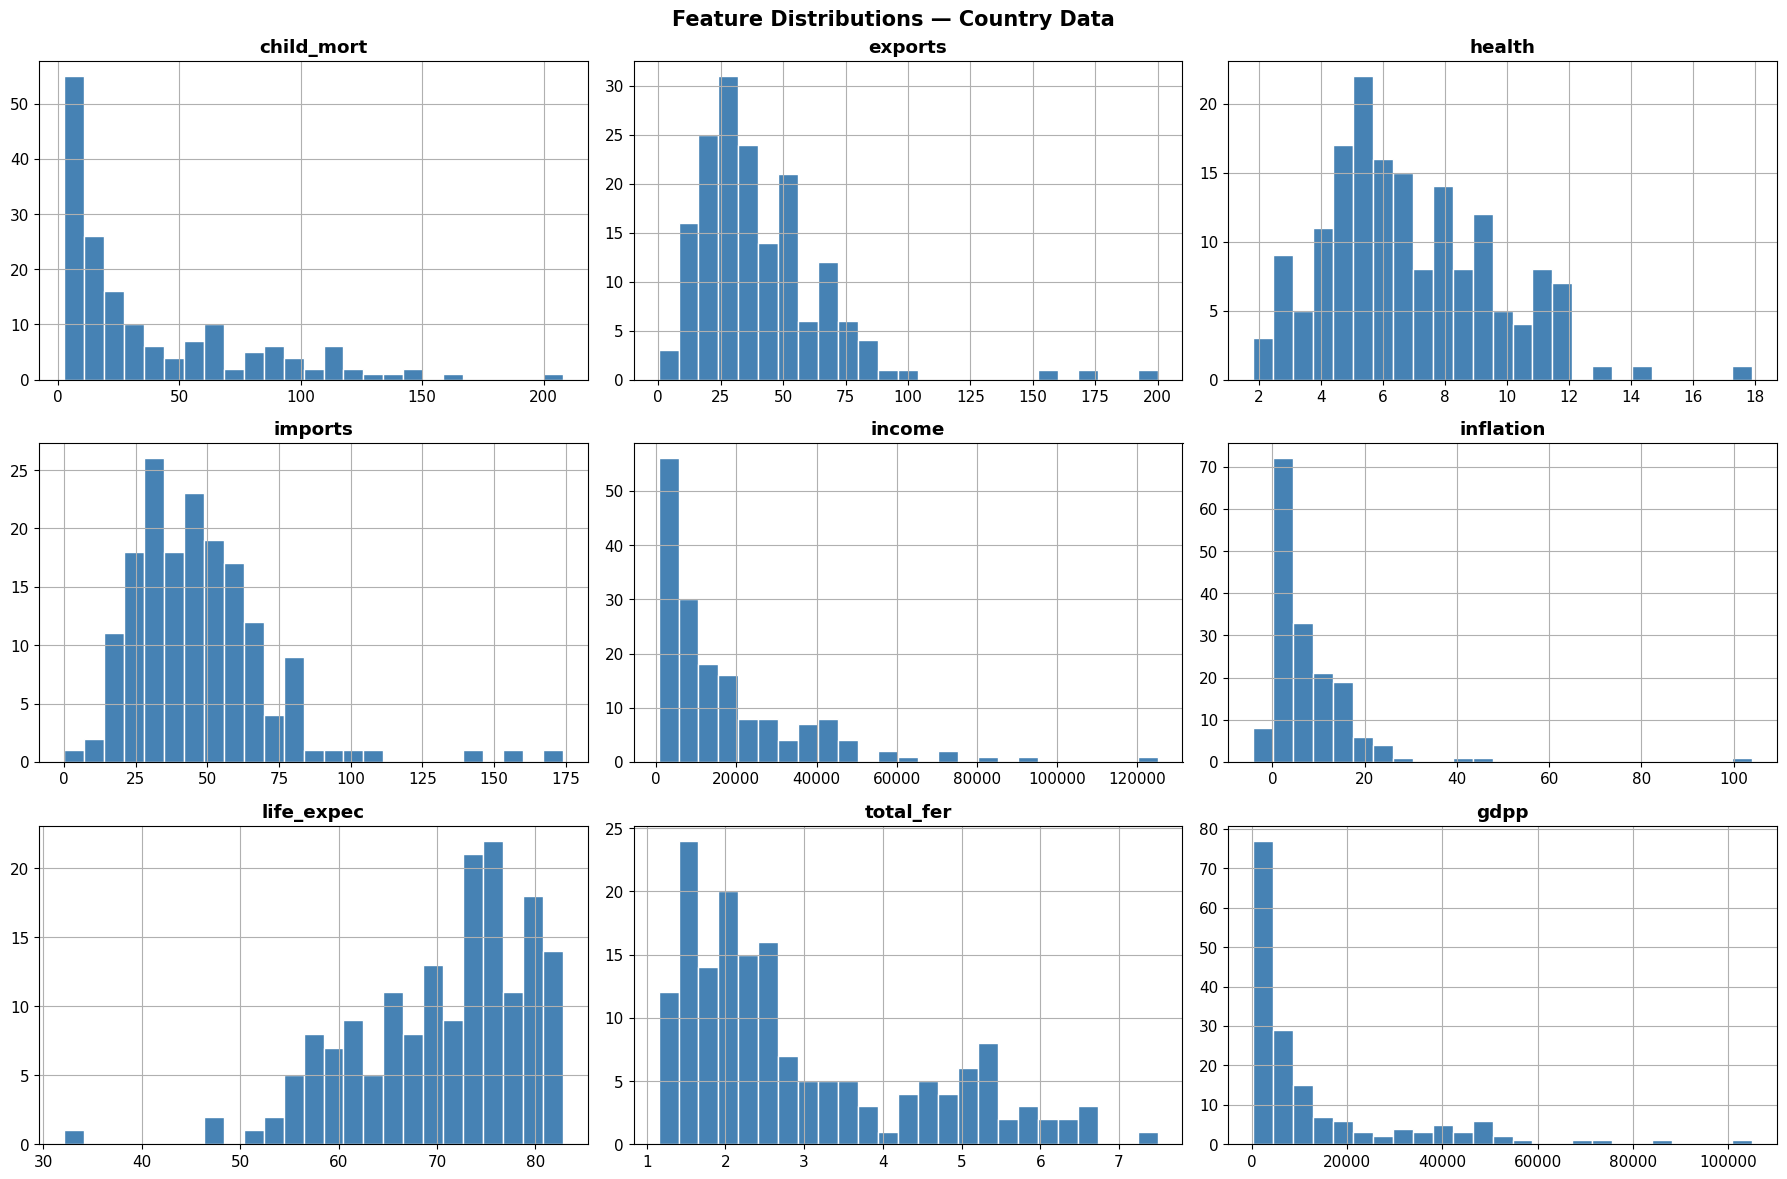

In [5]:
num_cols = ['child_mort','exports','health','imports','income',
            'inflation','life_expec','total_fer','gdpp']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
for i, col in enumerate(num_cols):
    ax = axes[i // 3][i % 3]
    df_raw[col].hist(ax=ax, bins=25, edgecolor='white', color='steelblue')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
fig.suptitle('Feature Distributions — Country Data', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


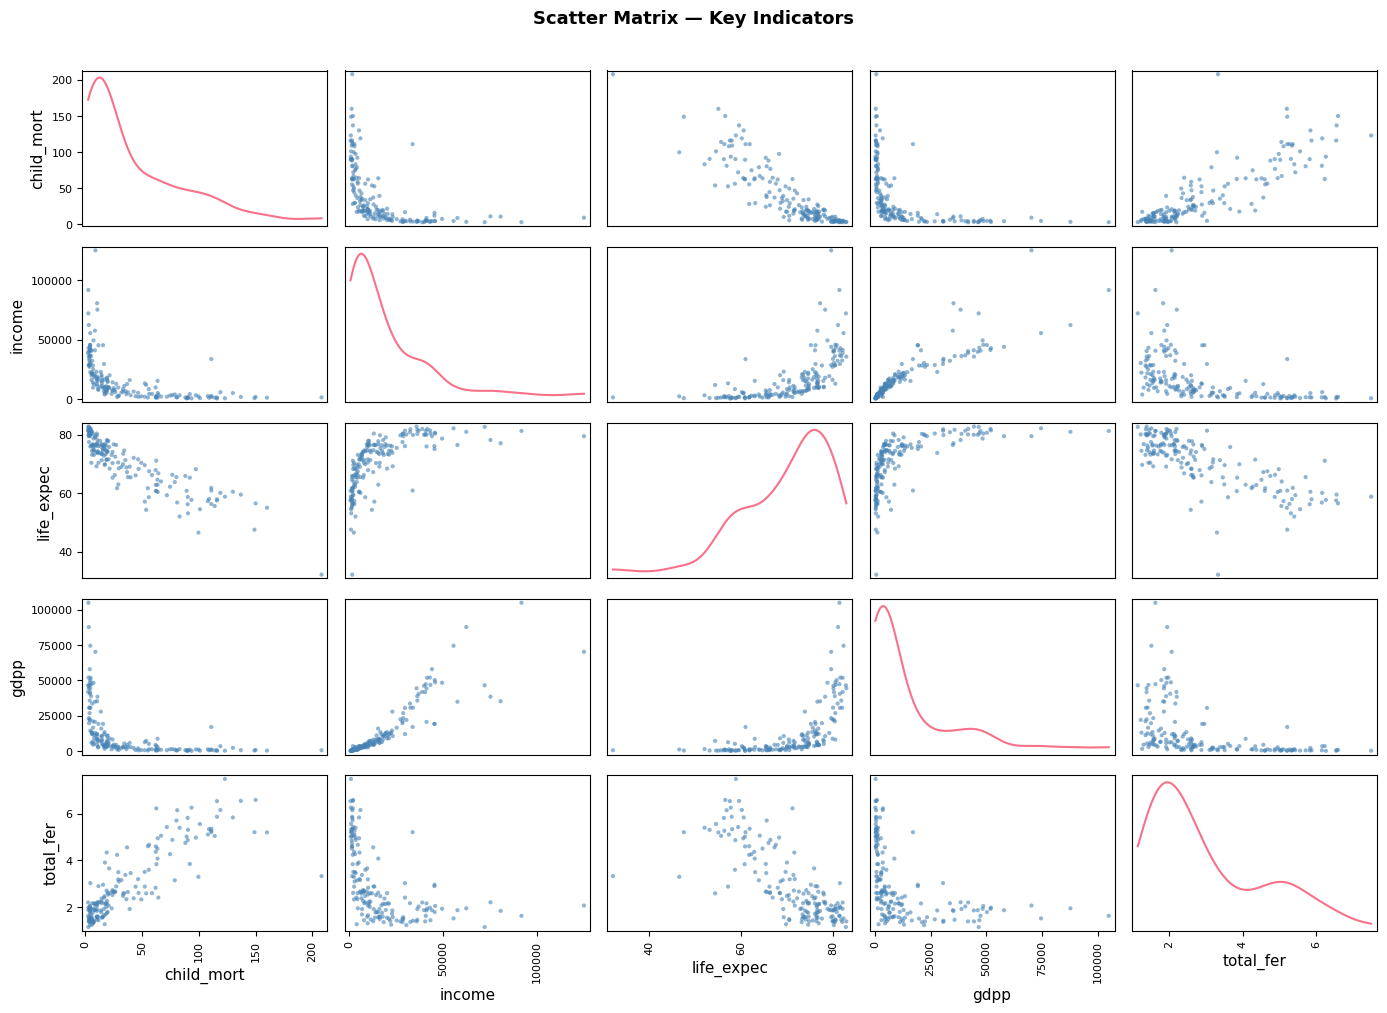

In [6]:
# Scatter matrix for key economic indicators
from pandas.plotting import scatter_matrix
key_cols = ['child_mort', 'income', 'life_expec', 'gdpp', 'total_fer']
scatter_matrix(df_raw[key_cols], figsize=(14, 10), diagonal='kde',
               alpha=0.6, color='steelblue')
plt.suptitle('Scatter Matrix — Key Indicators', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


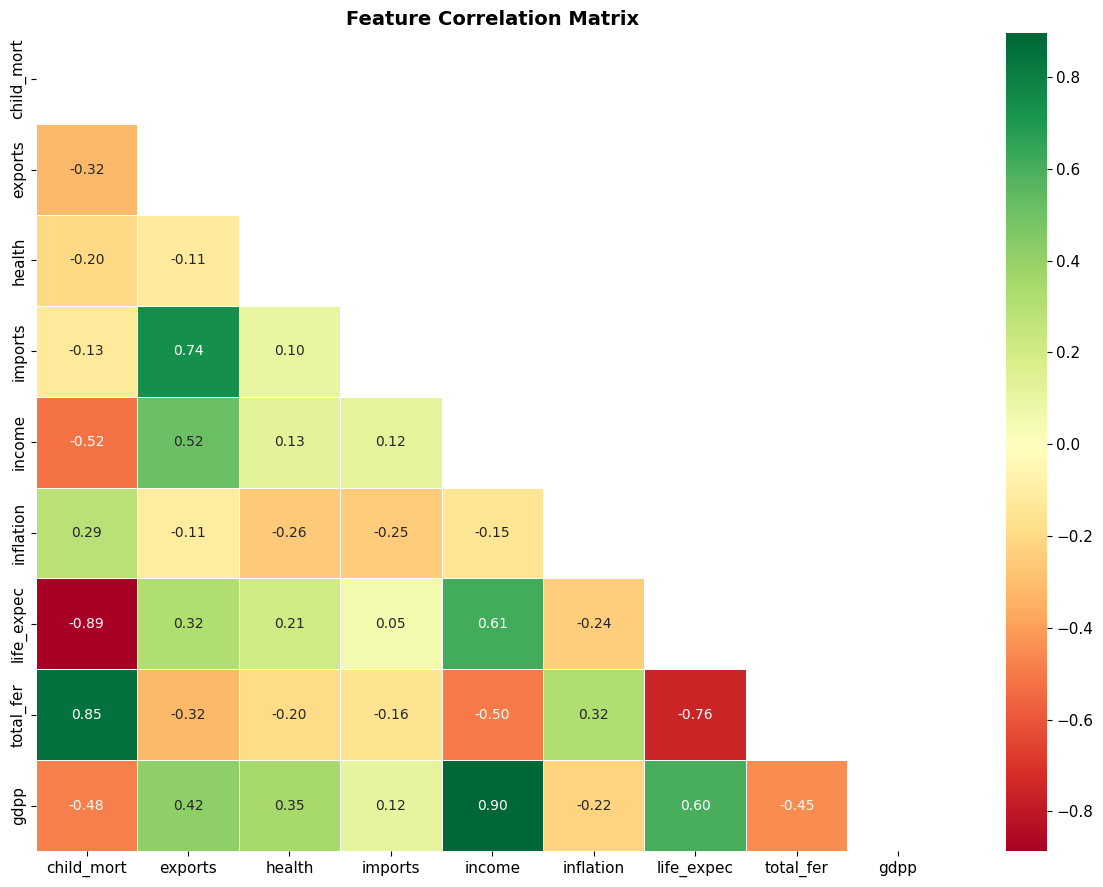

In [7]:
plt.figure(figsize=(12, 9))
corr = df_raw[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, annot_kws={'size': 10})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


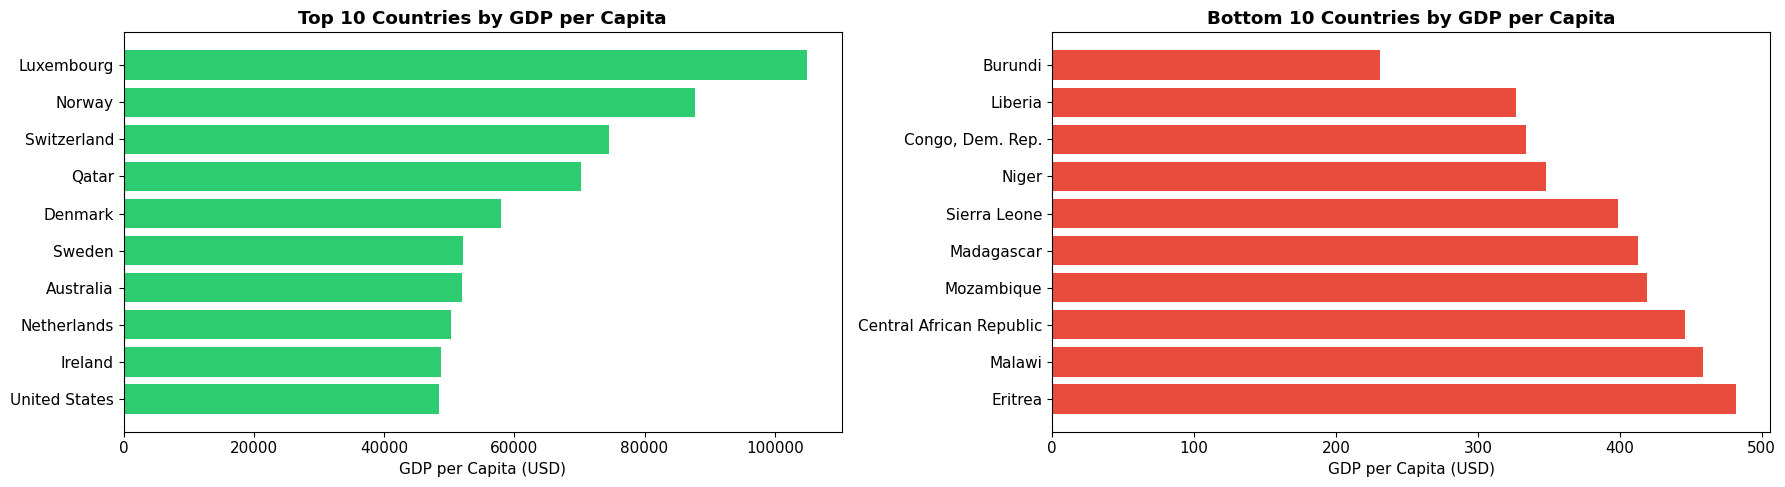

In [8]:
# Top 10 countries by GDP per capita
top10_gdpp = df_raw.nlargest(10, 'gdpp')[['country','gdpp','income','life_expec','child_mort']]
bottom10   = df_raw.nsmallest(10, 'gdpp')[['country','gdpp','income','life_expec','child_mort']]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
axes[0].barh(top10_gdpp['country'], top10_gdpp['gdpp'], color='#2ecc71')
axes[0].set_title('Top 10 Countries by GDP per Capita', fontweight='bold')
axes[0].set_xlabel('GDP per Capita (USD)')
axes[0].invert_yaxis()

axes[1].barh(bottom10['country'], bottom10['gdpp'], color='#e74c3c')
axes[1].set_title('Bottom 10 Countries by GDP per Capita', fontweight='bold')
axes[1].set_xlabel('GDP per Capita (USD)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


## 3. Feature Engineering & Preprocessing

**Classification target:** `is_developed`
Countries are labelled using a composite of `gdpp`, `income`, `life_expec`, and `child_mort`.
This mirrors how the UN/World Bank classify development levels.


In [9]:
df = df_raw.copy()

# ── Composite Development Score (z-score based) ──
from sklearn.preprocessing import StandardScaler as SS
_s = SS()
indicators = df[['gdpp','income','life_expec']].copy()
indicators['child_mort_inv'] = -df['child_mort']  # invert: lower = better
z = _s.fit_transform(indicators)
df['dev_score'] = z.mean(axis=1)

# Binary label: above median dev_score → developed
median_dev = df['dev_score'].median()
df['is_developed'] = (df['dev_score'] >= median_dev).astype(int)

print("Class distribution:")
vc = df['is_developed'].value_counts()
print(f"  Developing (0): {vc[0]}  ({vc[0]/len(df):.1%})")
print(f"  Developed  (1): {vc[1]}  ({vc[1]/len(df):.1%})")
print()

# Summary by class
print(df.groupby('is_developed')[num_cols].mean().round(2).to_string())


Class distribution:
  Developing (0): 83  (49.7%)
  Developed  (1): 84  (50.3%)

              child_mort  exports  health  imports    income  inflation  life_expec  total_fer      gdpp
is_developed                                                                                            
0                  66.95    32.25    6.13    45.56   4851.12      10.28       63.70       4.01   2251.37
1                   9.93    49.86    7.49    48.20  29291.90       5.32       77.32       1.90  23549.40


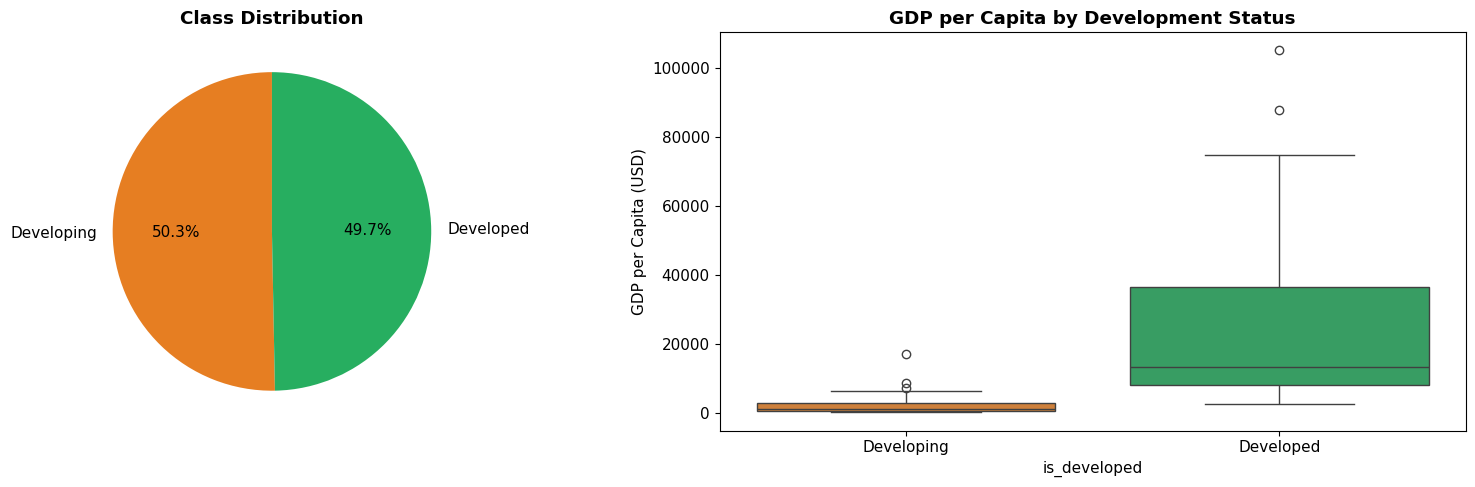

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Pie chart
vc = df['is_developed'].value_counts()
axes[0].pie(vc, labels=['Developing','Developed'], autopct='%1.1f%%',
            colors=['#e67e22','#27ae60'], startangle=90)
axes[0].set_title('Class Distribution', fontweight='bold')

# Box plots — gdpp by class
sns.boxplot(x='is_developed', y='gdpp', data=df, ax=axes[1],
            palette=['#e67e22','#27ae60'])
axes[1].set_title('GDP per Capita by Development Status', fontweight='bold')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Developing','Developed'])
axes[1].set_ylabel('GDP per Capita (USD)')

plt.tight_layout()
plt.show()


In [11]:
FEATURES = num_cols   # 9 numeric features
TARGET   = 'is_developed'

X = df[FEATURES].values
y = df[TARGET].values
countries = df['country'].values

# Train / test split  (stratified — important for small dataset)
X_train, X_test, y_train, y_test, c_train, c_test = train_test_split(
    X, y, countries, test_size=0.2, random_state=42, stratify=y)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}  |  Test: {X_test_s.shape}")
print(f"Train developed: {y_train.mean():.1%}  |  Test developed: {y_test.mean():.1%}")


Train: (133, 9)  |  Test: (34, 9)
Train developed: 50.4%  |  Test developed: 50.0%


### Helper Functions

In [12]:
results = {}
CV = 3   # small dataset — use 3-fold CV

def evaluate_model(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    y_pred  = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1] if hasattr(model, 'predict_proba') else None
    acc  = accuracy_score(yte, y_pred)
    f1   = f1_score(yte, y_pred, zero_division=0)
    prec = precision_score(yte, y_pred, zero_division=0)
    rec  = recall_score(yte, y_pred, zero_division=0)
    auc  = roc_auc_score(yte, y_proba) if y_proba is not None else None
    cv   = cross_val_score(model, Xtr, ytr, cv=CV, scoring='accuracy').mean()
    results[name] = dict(Accuracy=acc, F1=f1, Precision=prec, Recall=rec,
                         ROC_AUC=auc, CV_Acc=cv, model=model, y_proba=y_proba)
    auc_str = f'{auc:.4f}' if auc is not None else '  N/A '
    print(f'{name:28s}  Acc={acc:.4f}  F1={f1:.4f}  AUC={auc_str}  CV={cv:.4f}')
    return model

def plot_cm(name, yte, ypred):
    cm = confusion_matrix(yte, ypred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Developing','Developed'],
                yticklabels=['Developing','Developed'])
    plt.title(f'Confusion Matrix — {name}', fontweight='bold')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout(); plt.show()

print("Helpers ready. CV folds =", CV)


Helpers ready. CV folds = 3


## 4. Classification Models

### 4.1 Logistic Regression

Logistic Regression           Acc=0.8235  F1=0.8500  AUC=0.9896  CV=0.9697
Best C: 10


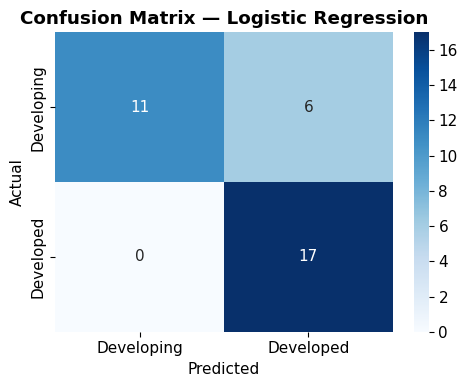

              precision    recall  f1-score   support

  Developing       1.00      0.65      0.79        17
   Developed       0.74      1.00      0.85        17

    accuracy                           0.82        34
   macro avg       0.87      0.82      0.82        34
weighted avg       0.87      0.82      0.82        34



In [13]:
lr = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    {'C': [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=CV, scoring='roc_auc', n_jobs=-1)
evaluate_model('Logistic Regression', lr, X_train_s, y_train, X_test_s, y_test)
print(f"Best C: {lr.best_params_['C']}")
plot_cm('Logistic Regression', y_test, lr.predict(X_test_s))
print(classification_report(y_test, lr.predict(X_test_s),
                             target_names=['Developing','Developed']))


### 4.2 Gaussian Naive Bayes

Naive Bayes                   Acc=0.8529  F1=0.8718  AUC=0.9931  CV=0.9623


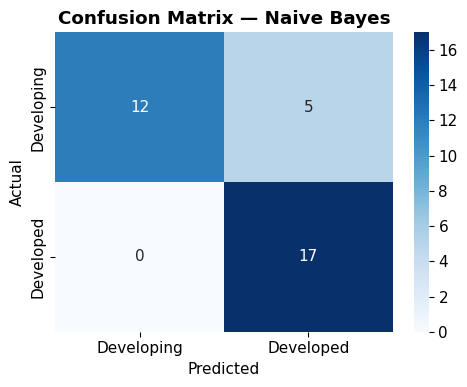

              precision    recall  f1-score   support

  Developing       1.00      0.71      0.83        17
   Developed       0.77      1.00      0.87        17

    accuracy                           0.85        34
   macro avg       0.89      0.85      0.85        34
weighted avg       0.89      0.85      0.85        34



In [14]:
nb = GaussianNB()
evaluate_model('Naive Bayes', nb, X_train_s, y_train, X_test_s, y_test)
plot_cm('Naive Bayes', y_test, nb.predict(X_test_s))
print(classification_report(y_test, nb.predict(X_test_s),
                             target_names=['Developing','Developed']))


### 4.3 K-Nearest Neighbors

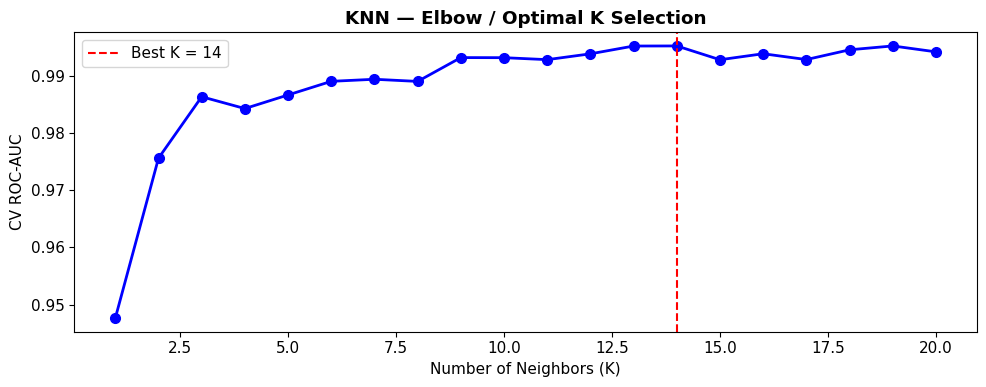

KNN                           Acc=0.7941  F1=0.8293  AUC=0.9619  CV=0.9623


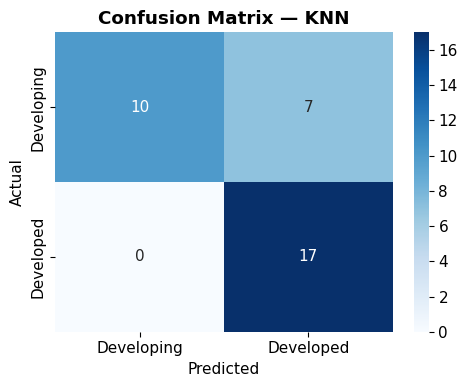

              precision    recall  f1-score   support

  Developing       1.00      0.59      0.74        17
   Developed       0.71      1.00      0.83        17

    accuracy                           0.79        34
   macro avg       0.85      0.79      0.79        34
weighted avg       0.85      0.79      0.79        34



In [15]:
k_range  = range(1, 21)
k_scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k),
                             X_train_s, y_train, cv=CV, scoring='roc_auc').mean()
            for k in k_range]

plt.figure(figsize=(10, 4))
plt.plot(k_range, k_scores, 'bo-', linewidth=2, markersize=7)
best_k = list(k_range)[np.argmax(k_scores)]
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.xlabel('Number of Neighbors (K)'); plt.ylabel('CV ROC-AUC')
plt.title('KNN — Elbow / Optimal K Selection', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

knn = KNeighborsClassifier(n_neighbors=best_k, weights='distance', p=2)
evaluate_model('KNN', knn, X_train_s, y_train, X_test_s, y_test)
plot_cm('KNN', y_test, knn.predict(X_test_s))

print(classification_report(y_test, knn.predict(X_test_s),
                             target_names=['Developing','Developed']))

### 4.4 Support Vector Machine (SVM)

SVM                           Acc=0.7941  F1=0.8293  AUC=0.9827  CV=0.9471
Best params: {'C': 1, 'kernel': 'linear'}


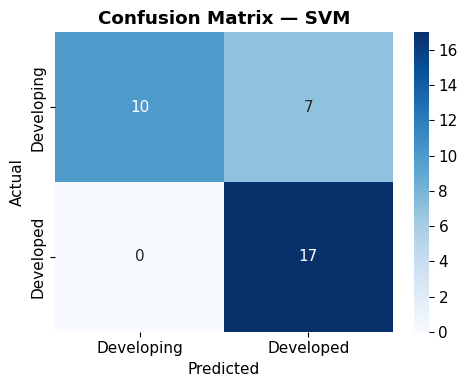

              precision    recall  f1-score   support

  Developing       1.00      0.59      0.74        17
   Developed       0.71      1.00      0.83        17

    accuracy                           0.79        34
   macro avg       0.85      0.79      0.79        34
weighted avg       0.85      0.79      0.79        34



In [16]:
svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    {'C': [0.01, 0.1, 1, 10, 100], 'kernel': ['rbf', 'linear', 'poly']},
    cv=CV, scoring='roc_auc', n_jobs=-1)
evaluate_model('SVM', svm, X_train_s, y_train, X_test_s, y_test)
print(f"Best params: {svm.best_params_}")
plot_cm('SVM', y_test, svm.predict(X_test_s))
print(classification_report(y_test, svm.predict(X_test_s),
                             target_names=['Developing','Developed']))


### 4.5 Decision Tree

Decision Tree                 Acc=0.7353  F1=0.7805  AUC=0.7353  CV=0.9697
Best params: {'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 2}


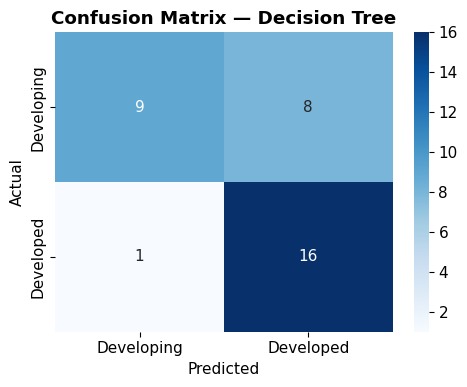

              precision    recall  f1-score   support

  Developing       0.90      0.53      0.67        17
   Developed       0.67      0.94      0.78        17

    accuracy                           0.74        34
   macro avg       0.78      0.74      0.72        34
weighted avg       0.78      0.74      0.72        34



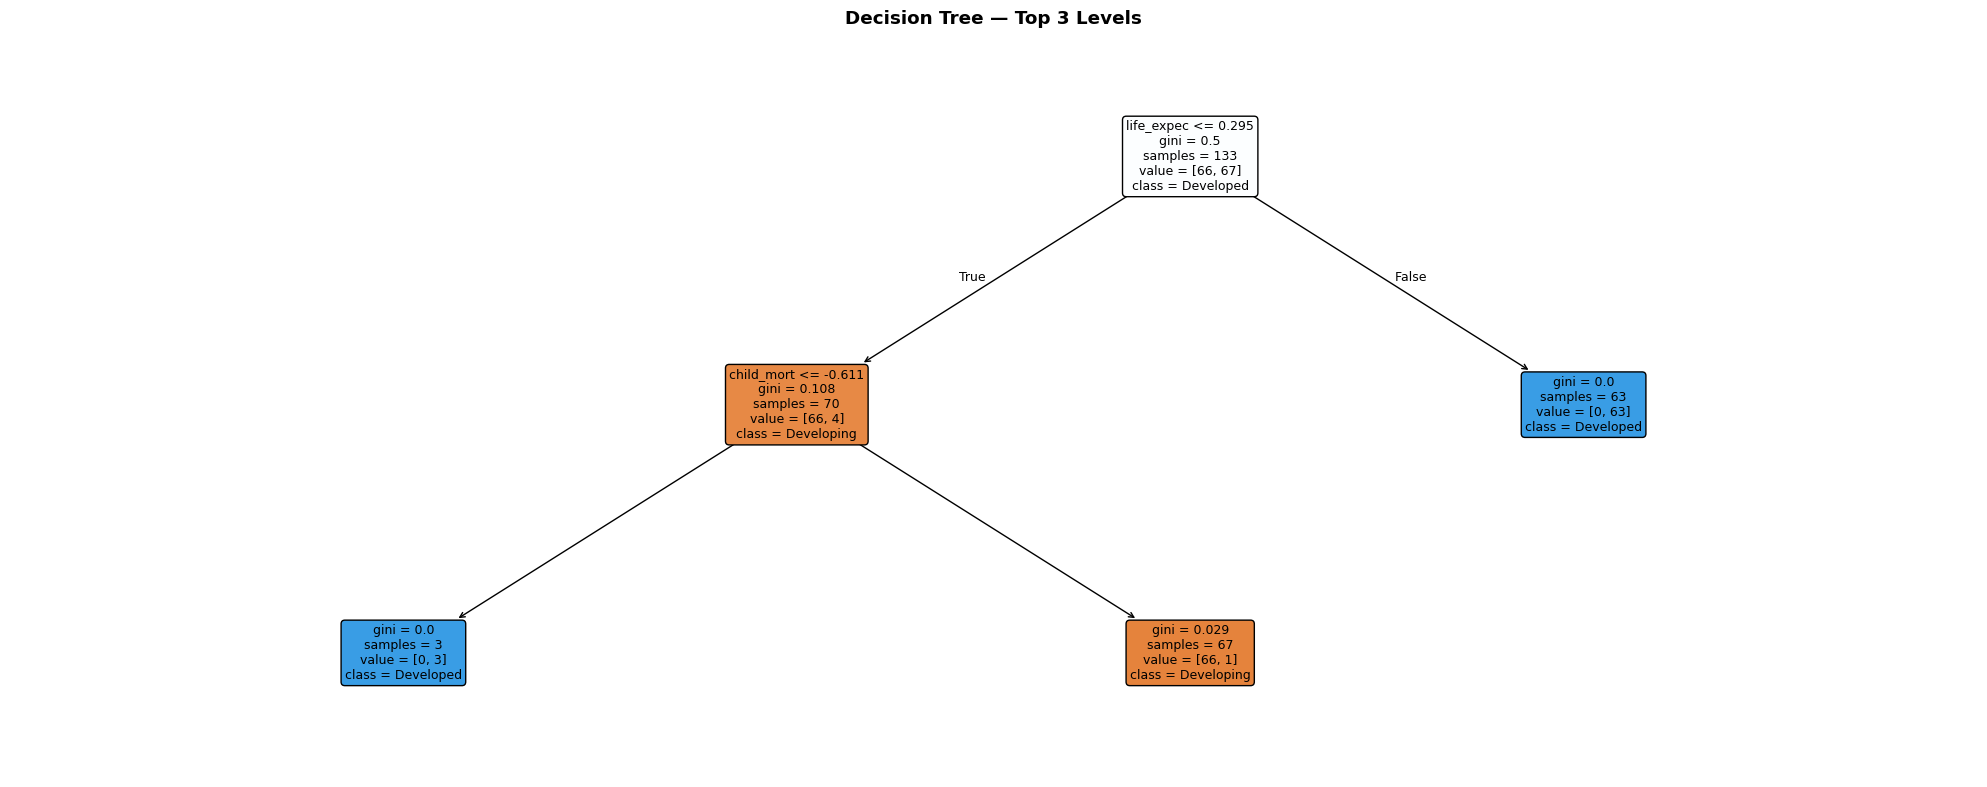

In [17]:
dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {'max_depth': [2, 3, 4, 5, None],
     'min_samples_split': [2, 5, 10],
     'criterion': ['gini', 'entropy']},
    cv=CV, scoring='roc_auc', n_jobs=-1)
evaluate_model('Decision Tree', dt, X_train_s, y_train, X_test_s, y_test)
print(f"Best params: {dt.best_params_}")
plot_cm('Decision Tree', y_test, dt.predict(X_test_s))
print(classification_report(y_test, dt.predict(X_test_s),
                             target_names=['Developing','Developed']))

plt.figure(figsize=(20, 8))
plot_tree(dt.best_estimator_, feature_names=FEATURES,
          class_names=['Developing','Developed'],
          max_depth=3, filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree — Top 3 Levels', fontweight='bold')
plt.tight_layout(); plt.show()

## 5. Evaluation Metrics — Classification Comparison

In [18]:
base_names = ['Logistic Regression','Naive Bayes','KNN','SVM','Decision Tree']
metrics    = ['Accuracy','F1','Precision','Recall','ROC_AUC','CV_Acc']
summ = pd.DataFrame({n: {m: results[n][m] for m in metrics} for n in base_names}).T
print("=== BASE CLASSIFIER RESULTS ===")
print(summ.round(4).to_string())


=== BASE CLASSIFIER RESULTS ===
                     Accuracy      F1  Precision  Recall  ROC_AUC  CV_Acc
Logistic Regression    0.8235  0.8500     0.7391  1.0000   0.9896  0.9697
Naive Bayes            0.8529  0.8718     0.7727  1.0000   0.9931  0.9623
KNN                    0.7941  0.8293     0.7083  1.0000   0.9619  0.9623
SVM                    0.7941  0.8293     0.7083  1.0000   0.9827  0.9471
Decision Tree          0.7353  0.7805     0.6667  0.9412   0.7353  0.9697


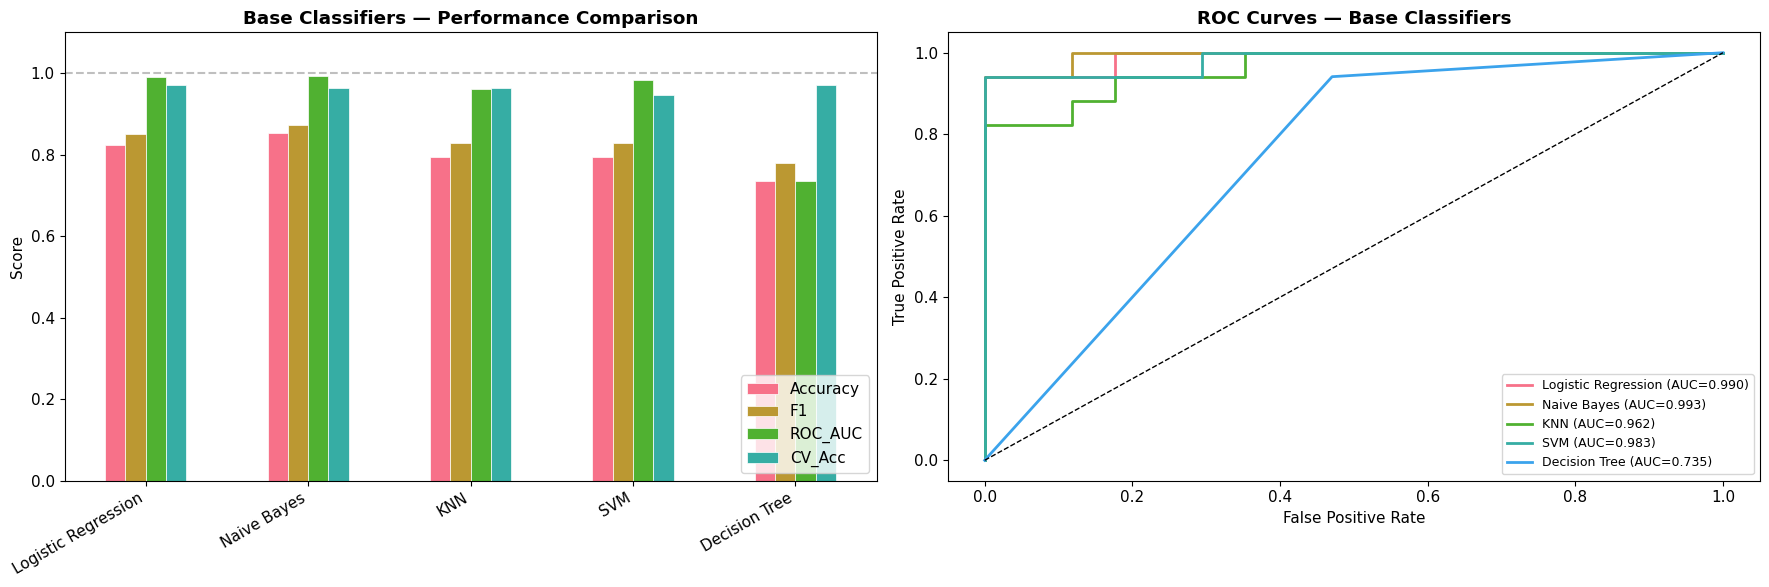

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

summ[['Accuracy','F1','ROC_AUC','CV_Acc']].plot(kind='bar', ax=axes[0], edgecolor='white', linewidth=0.5)
axes[0].set_title('Base Classifiers — Performance Comparison', fontweight='bold')
axes[0].set_ylabel('Score'); axes[0].set_ylim(0, 1.1)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].legend(loc='lower right'); axes[0].axhline(1.0, color='grey', linestyle='--', alpha=0.5)

for name in base_names:
    if results[name]['y_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, results[name]['y_proba'])
        axes[1].plot(fpr, tpr, linewidth=2,
                     label=f"{name} (AUC={results[name]['ROC_AUC']:.3f})")
axes[1].plot([0,1],[0,1],'k--', linewidth=1)
axes[1].set_title('ROC Curves — Base Classifiers', fontweight='bold')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right', fontsize=9)

plt.tight_layout(); plt.show()


## 6. Ensemble Methods

### 6.1 Random Forest & Feature Importance

In [20]:
rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {'n_estimators': [50, 100, 200],
     'max_depth': [None, 5, 10],
     'min_samples_split': [2, 5]},
    cv=CV, scoring='roc_auc', n_jobs=-1)
evaluate_model('Random Forest', rf, X_train_s, y_train, X_test_s, y_test)
print(f"Best params: {rf.best_params_}")


Random Forest                 Acc=0.8824  F1=0.8947  AUC=0.9896  CV=0.9773
Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


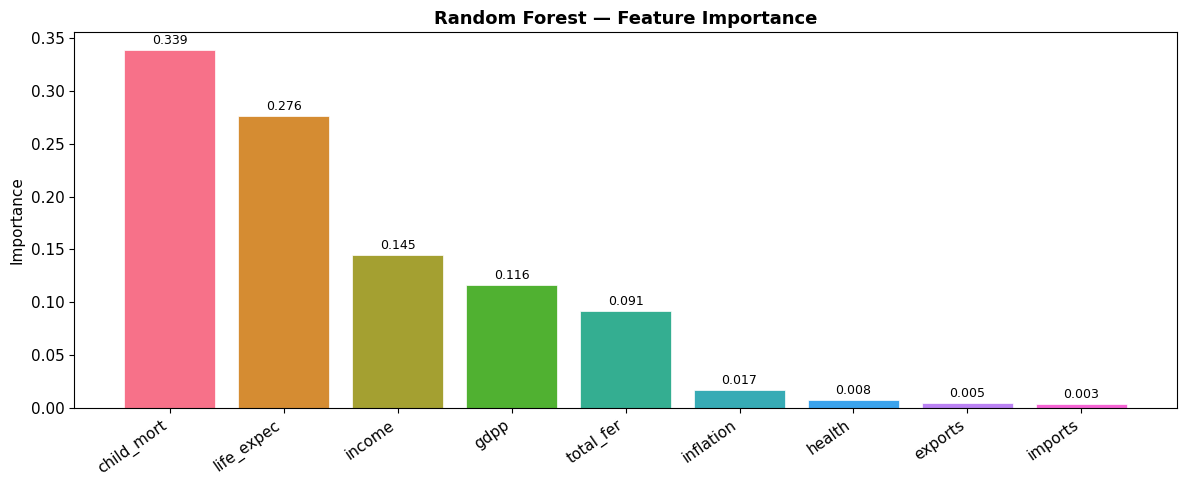


Top 5 predictors of development status:
child_mort    0.3386
life_expec    0.2760
income        0.1450
gdpp          0.1164
total_fer     0.0915


In [21]:
importances = rf.best_estimator_.feature_importances_
feat_imp    = pd.Series(importances, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
colors = sns.color_palette('husl', len(feat_imp))
bars = plt.bar(feat_imp.index, feat_imp.values, color=colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, feat_imp.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.003,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.title('Random Forest — Feature Importance', fontweight='bold', fontsize=13)
plt.ylabel('Importance'); plt.xticks(rotation=35, ha='right')
plt.tight_layout(); plt.show()

print("\nTop 5 predictors of development status:")
print(feat_imp.head().round(4).to_string())


### 6.2 AdaBoost

AdaBoost                      Acc=0.7941  F1=0.8205  AUC=0.9792  CV=0.9699
Best params: {'learning_rate': 0.1, 'n_estimators': 200}


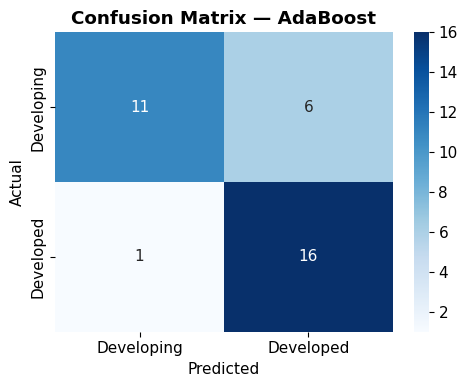

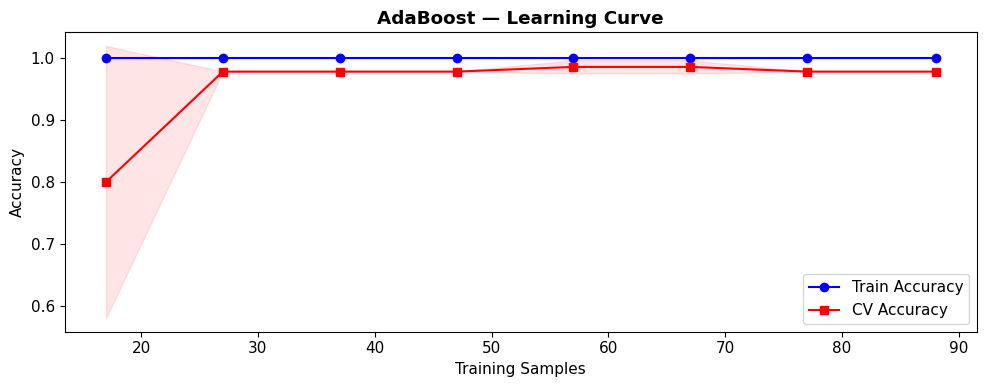

In [22]:
ada = GridSearchCV(
    AdaBoostClassifier(random_state=42, algorithm='SAMME'),
    {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 0.5, 1.0]},
    cv=CV, scoring='roc_auc', n_jobs=-1)
evaluate_model('AdaBoost', ada, X_train_s, y_train, X_test_s, y_test)
print(f"Best params: {ada.best_params_}")
plot_cm('AdaBoost', y_test, ada.predict(X_test_s))

# Learning curve — train vs test accuracy across estimator count
from sklearn.model_selection import learning_curve
best_ada = ada.best_estimator_
train_sizes, train_sc, test_sc = learning_curve(
    best_ada, X_train_s, y_train,
    cv=CV, train_sizes=np.linspace(0.2, 1.0, 8), scoring='accuracy')

plt.figure(figsize=(10, 4))
plt.plot(train_sizes, train_sc.mean(axis=1), 'b-o', label='Train Accuracy')
plt.plot(train_sizes, test_sc.mean(axis=1),  'r-s', label='CV Accuracy')
plt.fill_between(train_sizes,
                 train_sc.mean(axis=1) - train_sc.std(axis=1),
                 train_sc.mean(axis=1) + train_sc.std(axis=1), alpha=0.1, color='blue')
plt.fill_between(train_sizes,
                 test_sc.mean(axis=1) - test_sc.std(axis=1),
                 test_sc.mean(axis=1) + test_sc.std(axis=1), alpha=0.1, color='red')
plt.xlabel('Training Samples'); plt.ylabel('Accuracy')
plt.title('AdaBoost — Learning Curve', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

### 6.3 Gradient Boosting

Gradient Boosting             Acc=0.8529  F1=0.8718  AUC=0.9965  CV=0.9774
Best params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}


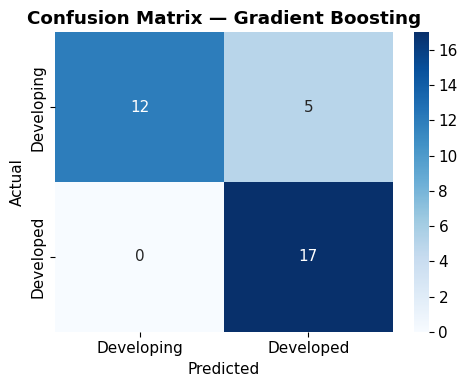

In [23]:
gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.05, 0.1],
     'max_depth': [2, 3, 5]},
    cv=CV, scoring='roc_auc', n_jobs=-1)
evaluate_model('Gradient Boosting', gb, X_train_s, y_train, X_test_s, y_test)
print(f"Best params: {gb.best_params_}")
plot_cm('Gradient Boosting', y_test, gb.predict(X_test_s))


### 6.4 XGBoost

XGBoost                       Acc=0.8529  F1=0.8718  AUC=0.9862  CV=0.9773
Best params: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 50, 'subsample': 0.8}


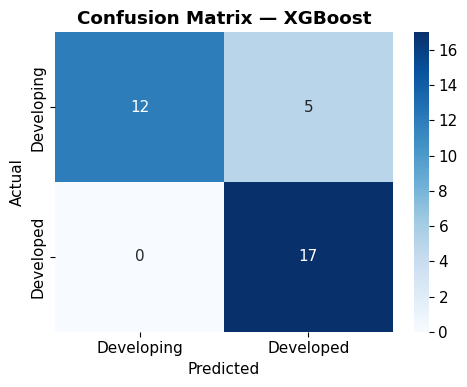

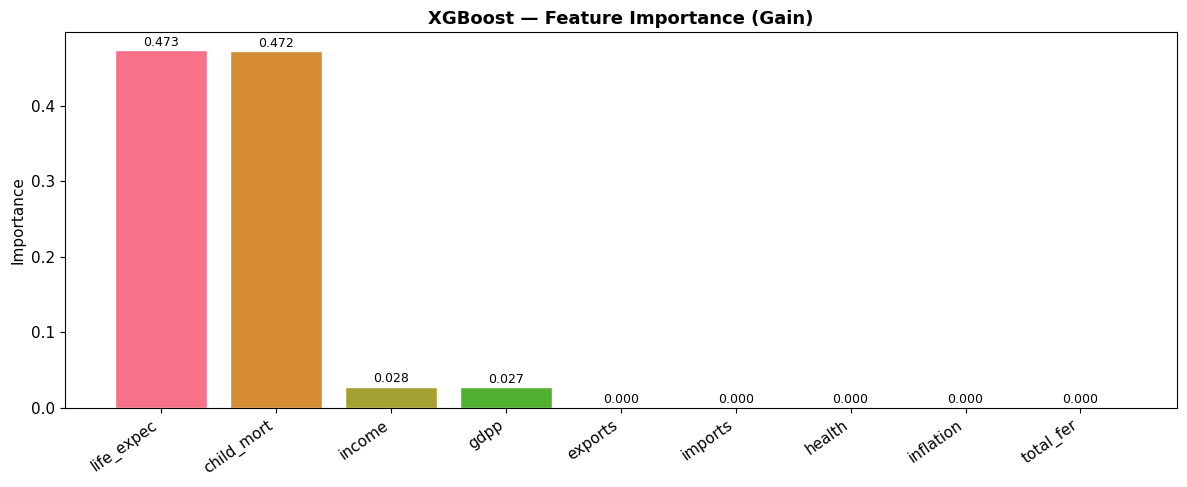

In [24]:
xgb_model = GridSearchCV(
    xgb.XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=1),
    {'n_estimators': [50, 100, 200], 'max_depth': [2, 3, 6],
     'learning_rate': [0.01, 0.05, 0.1], 'subsample': [0.8, 1.0]},
    cv=CV, scoring='roc_auc', n_jobs=-1)
evaluate_model('XGBoost', xgb_model, X_train_s, y_train, X_test_s, y_test)
print(f"Best params: {xgb_model.best_params_}")
plot_cm('XGBoost', y_test, xgb_model.predict(X_test_s))

# Feature importance with real feature names
xgb_imp = pd.Series(xgb_model.best_estimator_.feature_importances_,
                     index=FEATURES).sort_values(ascending=False)
plt.figure(figsize=(12, 5))
colors = sns.color_palette('husl', len(xgb_imp))
bars = plt.bar(xgb_imp.index, xgb_imp.values, color=colors, edgecolor='white')
for bar, val in zip(bars, xgb_imp.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.002,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.title('XGBoost — Feature Importance (Gain)', fontweight='bold', fontsize=13)
plt.ylabel('Importance'); plt.xticks(rotation=35, ha='right')
plt.tight_layout(); plt.show()

### 6.5 LightGBM

LightGBM                      Acc=0.7647  F1=0.8095  AUC=0.9723  CV=0.9773
Best params: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 200, 'num_leaves': 15}


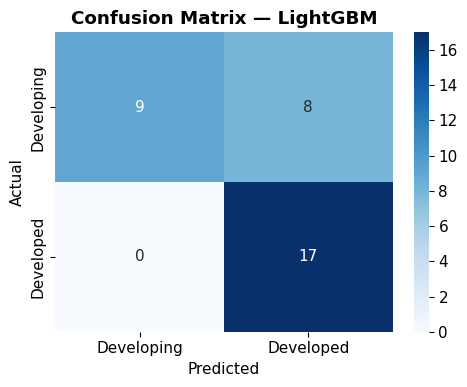

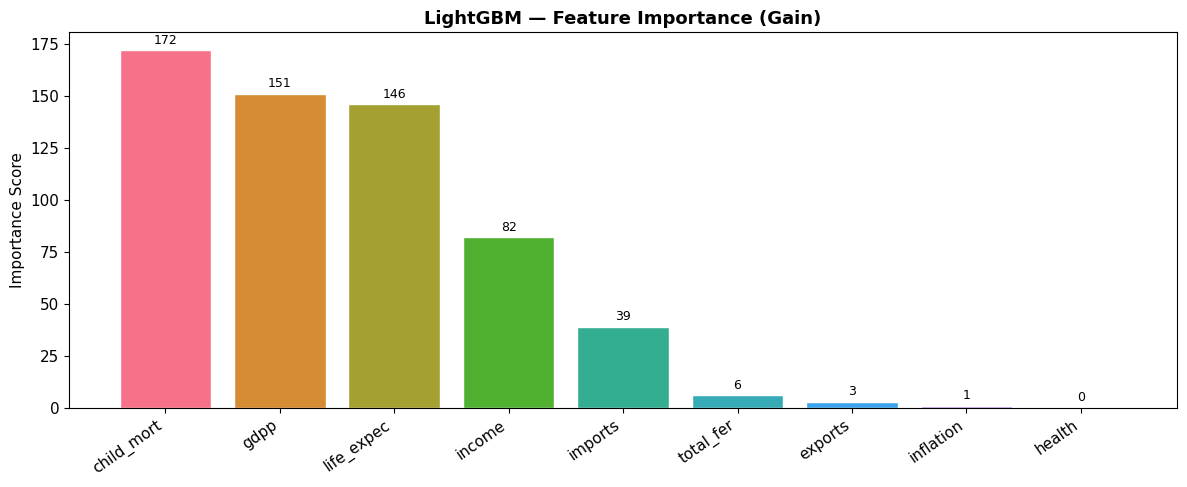

In [25]:
lgb_model = GridSearchCV(
    lgb.LGBMClassifier(random_state=42, verbose=-1),
    {'n_estimators': [50, 100, 200], 'max_depth': [2, 3, 6],
     'learning_rate': [0.01, 0.05, 0.1], 'num_leaves': [15, 31, 63]},
    cv=CV, scoring='roc_auc', n_jobs=-1)
evaluate_model('LightGBM', lgb_model, X_train_s, y_train, X_test_s, y_test)
print(f"Best params: {lgb_model.best_params_}")
plot_cm('LightGBM', y_test, lgb_model.predict(X_test_s))

# Feature importance with real feature names
lgb_imp = pd.Series(lgb_model.best_estimator_.feature_importances_,
                     index=FEATURES).sort_values(ascending=False)
plt.figure(figsize=(12, 5))
colors = sns.color_palette('husl', len(lgb_imp))
bars = plt.bar(lgb_imp.index, lgb_imp.values, color=colors, edgecolor='white')
for bar, val in zip(bars, lgb_imp.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + max(lgb_imp.values)*0.01,
             f'{val:.0f}', ha='center', va='bottom', fontsize=9)
plt.title('LightGBM — Feature Importance (Gain)', fontweight='bold', fontsize=13)
plt.ylabel('Importance Score'); plt.xticks(rotation=35, ha='right')
plt.tight_layout(); plt.show()

### 6.6 Stacking Ensemble

Stacking                      Acc=0.7647  F1=0.8095  AUC=0.9758  CV=0.9848


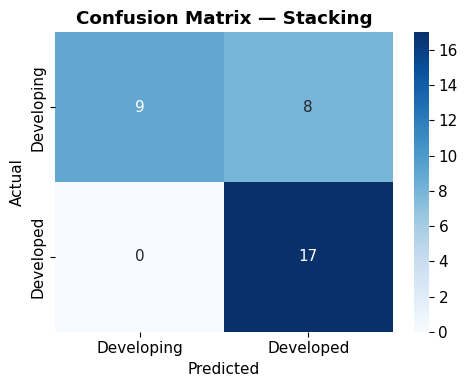

              precision    recall  f1-score   support

  Developing       1.00      0.53      0.69        17
   Developed       0.68      1.00      0.81        17

    accuracy                           0.76        34
   macro avg       0.84      0.76      0.75        34
weighted avg       0.84      0.76      0.75        34



In [26]:
base_estimators = [
    ('lr',  LogisticRegression(C=1, max_iter=2000, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=best_k, weights='distance')),
    ('dt',  DecisionTreeClassifier(max_depth=3, random_state=42)),
    ('rf',  RandomForestClassifier(n_estimators=100, random_state=42)),
    ('gb',  GradientBoostingClassifier(n_estimators=100, random_state=42)),
]
stacking = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(C=1, max_iter=2000, random_state=42),
    cv=CV, n_jobs=-1, passthrough=False)
evaluate_model('Stacking', stacking, X_train_s, y_train, X_test_s, y_test)
plot_cm('Stacking', y_test, stacking.predict(X_test_s))
print(classification_report(y_test, stacking.predict(X_test_s),
                             target_names=['Developing','Developed']))


## 7. Full Model Leaderboard

In [27]:
all_names = list(results.keys())
comp_df = pd.DataFrame(
    {m: {n: results[n][m] for n in all_names}
     for m in ['Accuracy','F1','Precision','Recall','ROC_AUC','CV_Acc']}
).sort_values('ROC_AUC', ascending=False)

print("=== MODEL LEADERBOARD (sorted by ROC-AUC) ===")
print(comp_df.round(4).to_string())


=== MODEL LEADERBOARD (sorted by ROC-AUC) ===
                     Accuracy      F1  Precision  Recall  ROC_AUC  CV_Acc
Gradient Boosting      0.8529  0.8718     0.7727  1.0000   0.9965  0.9774
Naive Bayes            0.8529  0.8718     0.7727  1.0000   0.9931  0.9623
Random Forest          0.8824  0.8947     0.8095  1.0000   0.9896  0.9773
Logistic Regression    0.8235  0.8500     0.7391  1.0000   0.9896  0.9697
XGBoost                0.8529  0.8718     0.7727  1.0000   0.9862  0.9773
SVM                    0.7941  0.8293     0.7083  1.0000   0.9827  0.9471
AdaBoost               0.7941  0.8205     0.7273  0.9412   0.9792  0.9699
Stacking               0.7647  0.8095     0.6800  1.0000   0.9758  0.9848
LightGBM               0.7647  0.8095     0.6800  1.0000   0.9723  0.9773
KNN                    0.7941  0.8293     0.7083  1.0000   0.9619  0.9623
Decision Tree          0.7353  0.7805     0.6667  0.9412   0.7353  0.9697


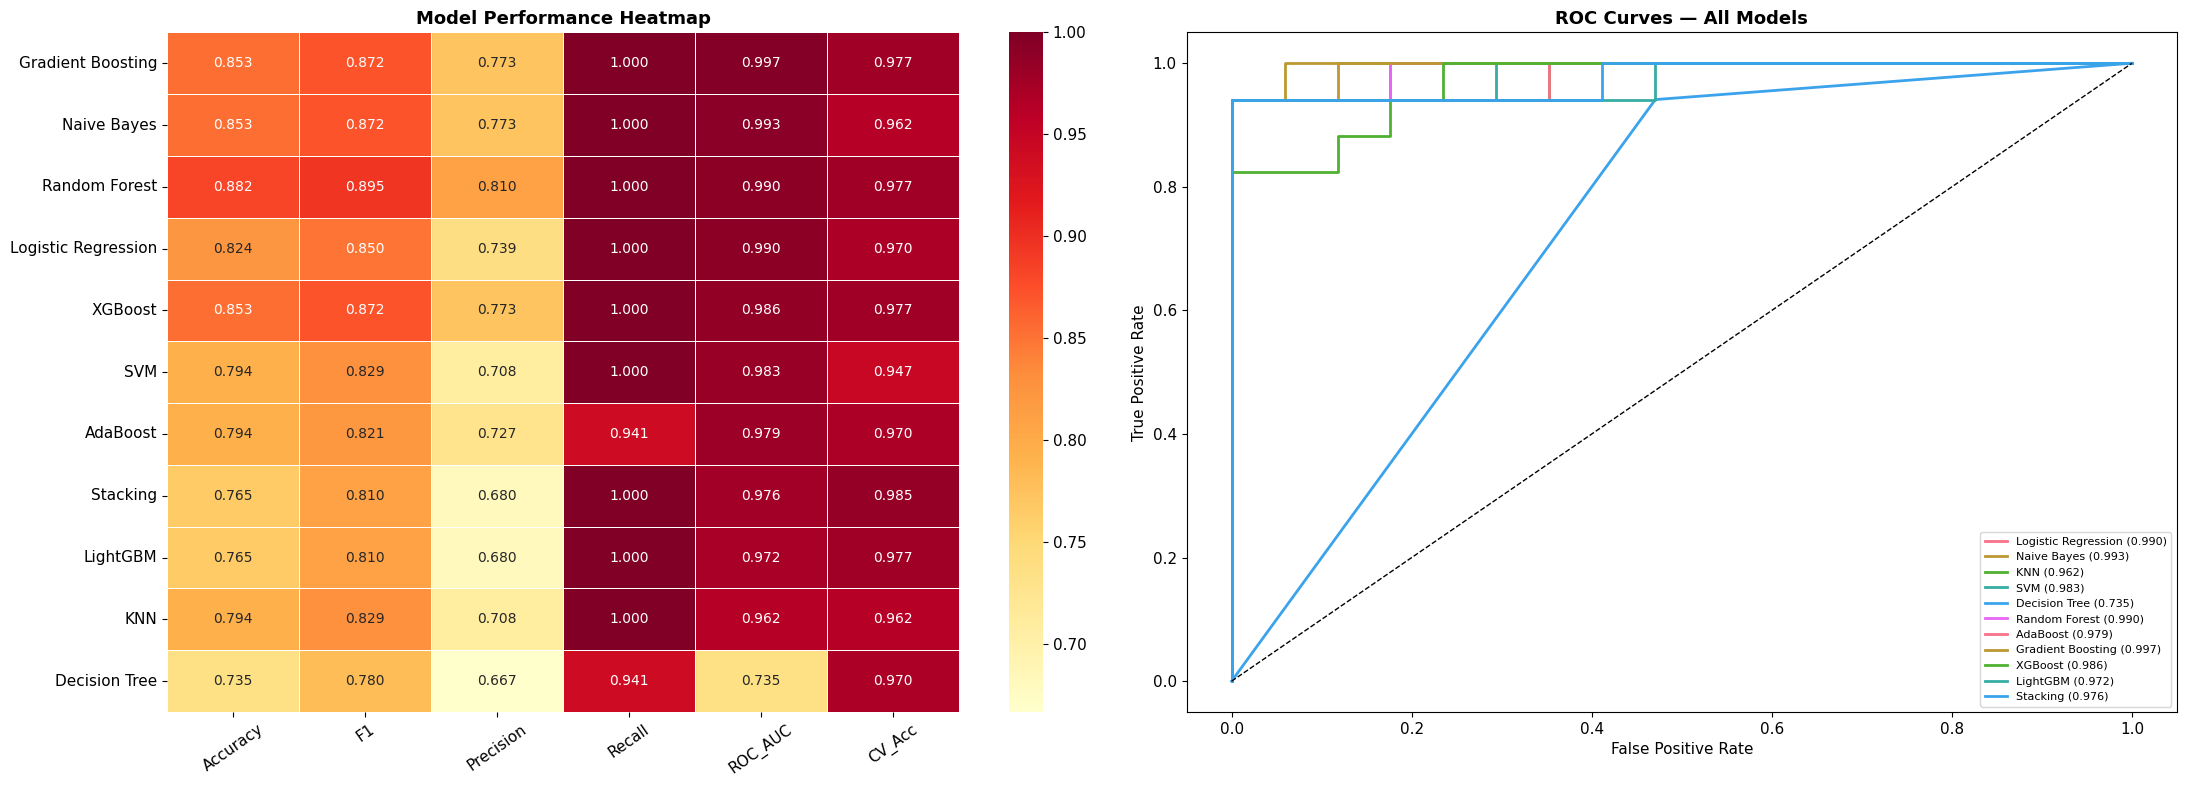

Best model: Gradient Boosting  (AUC = 0.9965)


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

sns.heatmap(comp_df[['Accuracy','F1','Precision','Recall','ROC_AUC','CV_Acc']].astype(float),
            annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0],
            linewidths=0.5, annot_kws={'size': 10})
axes[0].set_title('Model Performance Heatmap', fontweight='bold', fontsize=13)
axes[0].tick_params(axis='x', rotation=35)

for name in all_names:
    if results[name]['y_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, results[name]['y_proba'])
        axes[1].plot(fpr, tpr, linewidth=2,
                     label=f"{name} ({results[name]['ROC_AUC']:.3f})")
axes[1].plot([0,1],[0,1],'k--', linewidth=1)
axes[1].set_title('ROC Curves — All Models', fontweight='bold', fontsize=13)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout(); plt.show()
best_m = comp_df['ROC_AUC'].idxmax()
print(f"Best model: {best_m}  (AUC = {comp_df.loc[best_m,'ROC_AUC']:.4f})")


## 8. Clustering — Country Segmentation

We cluster all 167 countries using all 9 numeric features.
PCA reduces to 2D for visualisation — country names are annotated for context.


In [29]:
X_clust  = scaler.fit_transform(df[FEATURES].values)
countries_all = df['country'].values

pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust)
print(f"PCA variance explained by 2 components: {pca.explained_variance_ratio_.sum():.1%}")
print(f"PC1: {pca.explained_variance_ratio_[0]:.1%}  |  PC2: {pca.explained_variance_ratio_[1]:.1%}")

def plot_clusters(labels, title, annotate=False):
    n_c   = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int((labels == -1).sum())
    plt.figure(figsize=(12, 8))
    sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10',
                     alpha=0.75, s=60, edgecolors='white', linewidths=0.5)
    plt.colorbar(sc)
    if annotate:
        for i, cname in enumerate(countries_all):
            if labels[i] != -1:
                plt.annotate(cname, (X_pca[i, 0], X_pca[i, 1]),
                             fontsize=5.5, alpha=0.75)
    plt.title(f'{title}  |  Clusters={n_c}  Noise={n_noise}', fontweight='bold', fontsize=13)
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    plt.tight_layout(); plt.show()
    return n_c


PCA variance explained by 2 components: 63.1%
PC1: 46.0%  |  PC2: 17.2%


### 8.1 K-Means Clustering

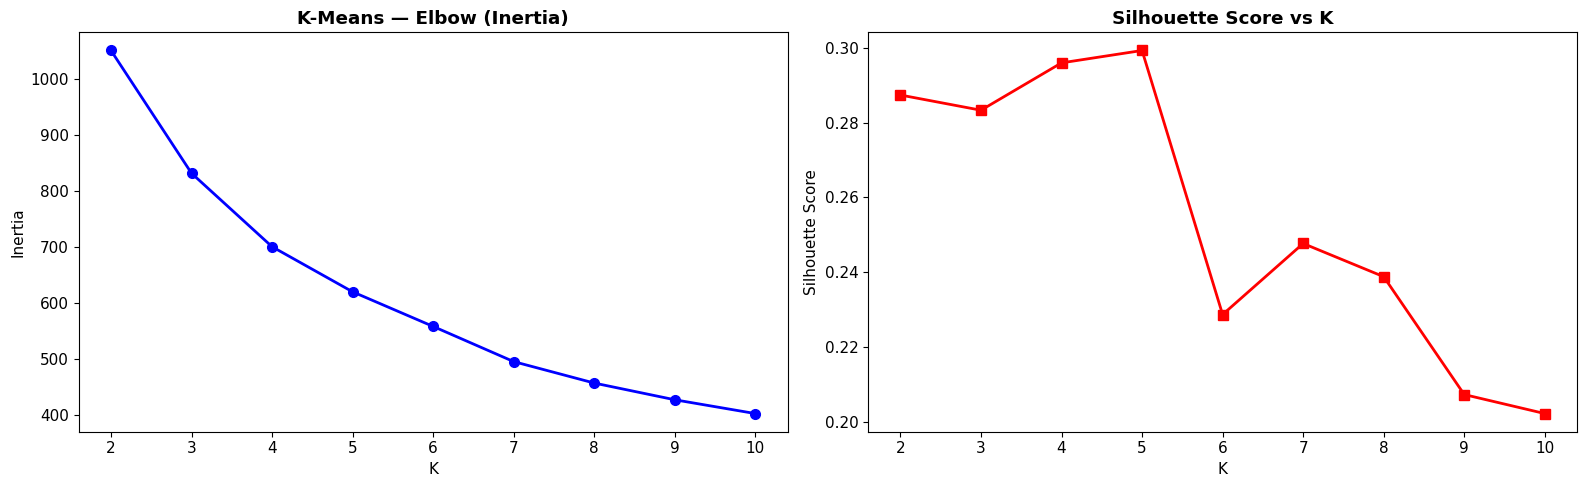

Optimal K (max silhouette): 5  — Silhouette=0.2993


In [30]:
inertias   = []
sil_scores = []
K_range    = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_clust)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clust, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=7)
axes[0].set_title('K-Means — Elbow (Inertia)', fontweight='bold')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, 'rs-', linewidth=2, markersize=7)
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')

plt.tight_layout(); plt.show()

best_k_km = list(K_range)[np.argmax(sil_scores)]
print(f"Optimal K (max silhouette): {best_k_km}  — Silhouette={max(sil_scores):.4f}")


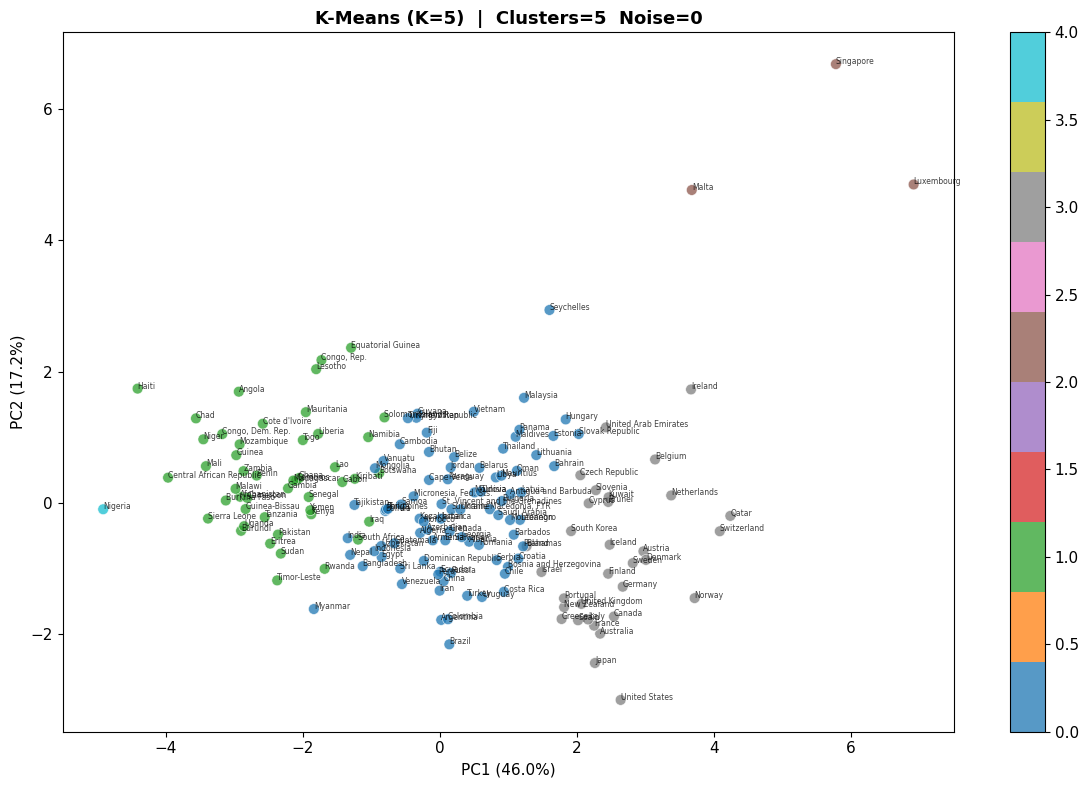

=== Cluster Mean Profiles ===
                child_mort  exports  health  imports    income  inflation  life_expec  total_fer      gdpp
KMeans_Cluster                                                                                            
0                    21.61    40.98    6.17    47.52  12801.07       7.62       73.00       2.28   6581.81
1                    90.79    29.66    6.46    43.68   3870.70       9.95       59.21       4.97   1900.26
2                     4.13   176.00    6.79   156.67  64033.33       2.47       81.43       1.38  57566.67
3                     5.18    46.12    9.09    40.58  44021.88       2.51       80.08       1.79  42118.75
4                   130.00    25.30    5.07    17.40   5150.00     104.00       60.50       5.84   2330.00


In [31]:
km_best   = KMeans(n_clusters=best_k_km, init='k-means++', n_init=10, random_state=42)
km_best.fit(X_clust)
km_labels = km_best.labels_

plot_clusters(km_labels, f'K-Means (K={best_k_km})', annotate=True)

df['KMeans_Cluster'] = km_labels
profile = df.groupby('KMeans_Cluster')[FEATURES].mean().round(2)
print("=== Cluster Mean Profiles ===")
print(profile.to_string())


### 8.2 K-Medoids Clustering

Approx medoid countries: ['Jamaica', 'Malawi', 'Singapore', 'Finland', 'Nigeria']


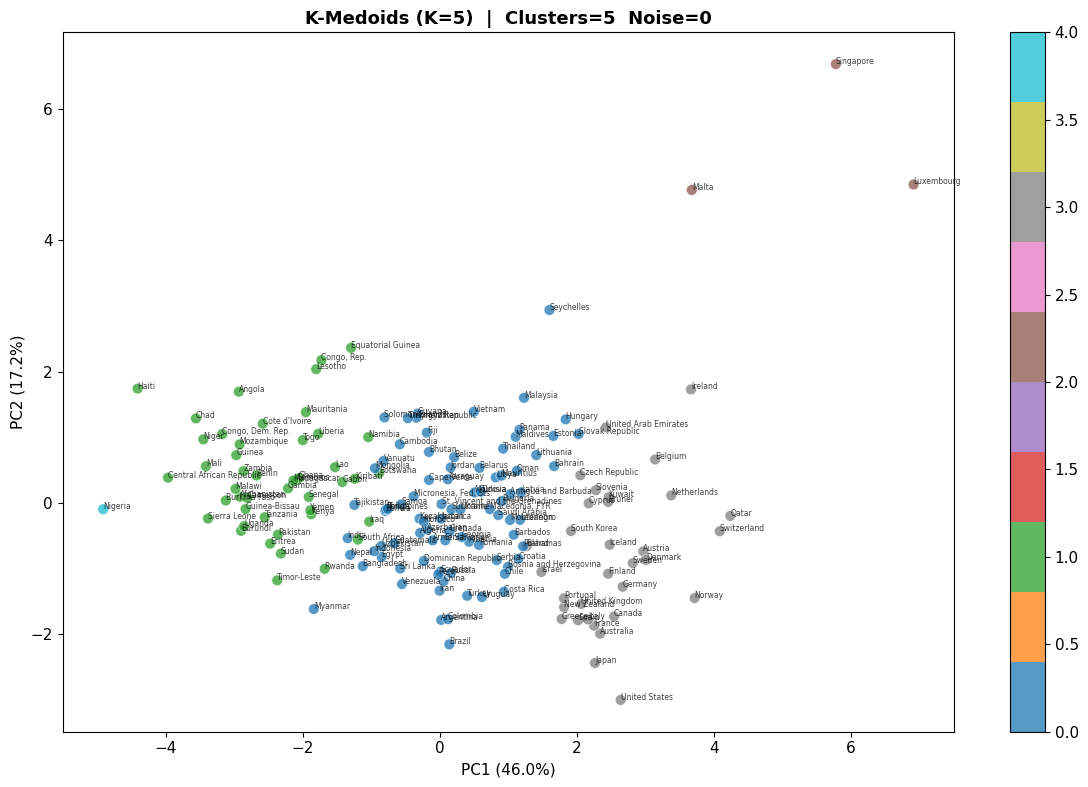

K-Medoids Silhouette: 0.2999


In [32]:
if KMEDOIDS_AVAILABLE:
    km_med      = KMedoids(n_clusters=best_k_km, random_state=42, method='pam')
    km_med.fit(X_clust)
    kmed_labels = km_med.labels_
    medoids     = km_med.medoid_indices_
    print(f"Medoid countries: {[countries_all[i] for i in medoids]}")
else:
    from sklearn.metrics import pairwise_distances_argmin_min
    km_tmp = KMeans(n_clusters=best_k_km, init='k-means++', n_init=10, random_state=42)
    km_tmp.fit(X_clust)
    medoid_idxs, _ = pairwise_distances_argmin_min(km_tmp.cluster_centers_, X_clust)
    km_fb = KMeans(n_clusters=best_k_km, init=X_clust[medoid_idxs], n_init=1, random_state=42)
    km_fb.fit(X_clust)
    kmed_labels = km_fb.labels_
    print(f"Approx medoid countries: {[countries_all[i] for i in medoid_idxs]}")

plot_clusters(kmed_labels, f'K-Medoids (K={best_k_km})', annotate=True)
print(f"K-Medoids Silhouette: {silhouette_score(X_clust, kmed_labels):.4f}")


### 8.3 DBSCAN Clustering

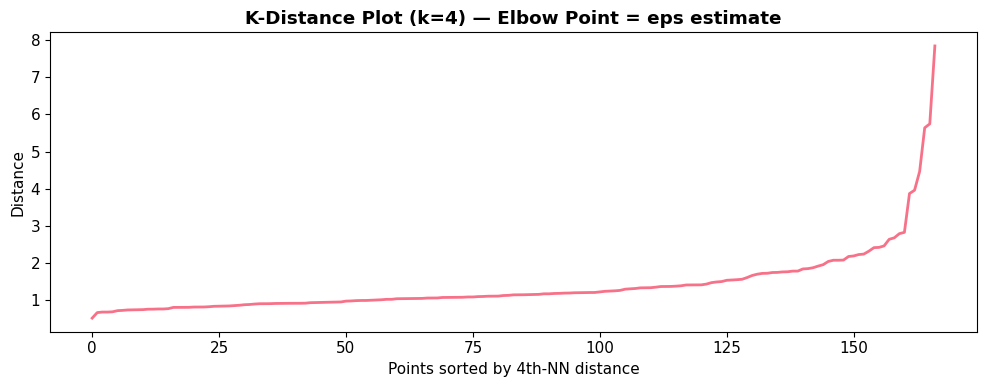

In [33]:
# K-distance plot to choose eps
nn = NearestNeighbors(n_neighbors=4)
nn.fit(X_clust)
distances, _ = nn.kneighbors(X_clust)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(10, 4))
plt.plot(k_dist, linewidth=2)
plt.title('K-Distance Plot (k=4) — Elbow Point = eps estimate', fontweight='bold')
plt.xlabel('Points sorted by 4th-NN distance'); plt.ylabel('Distance')
plt.tight_layout(); plt.show()


Best DBSCAN params: eps=0.8, min_samples=5, silhouette=0.4406


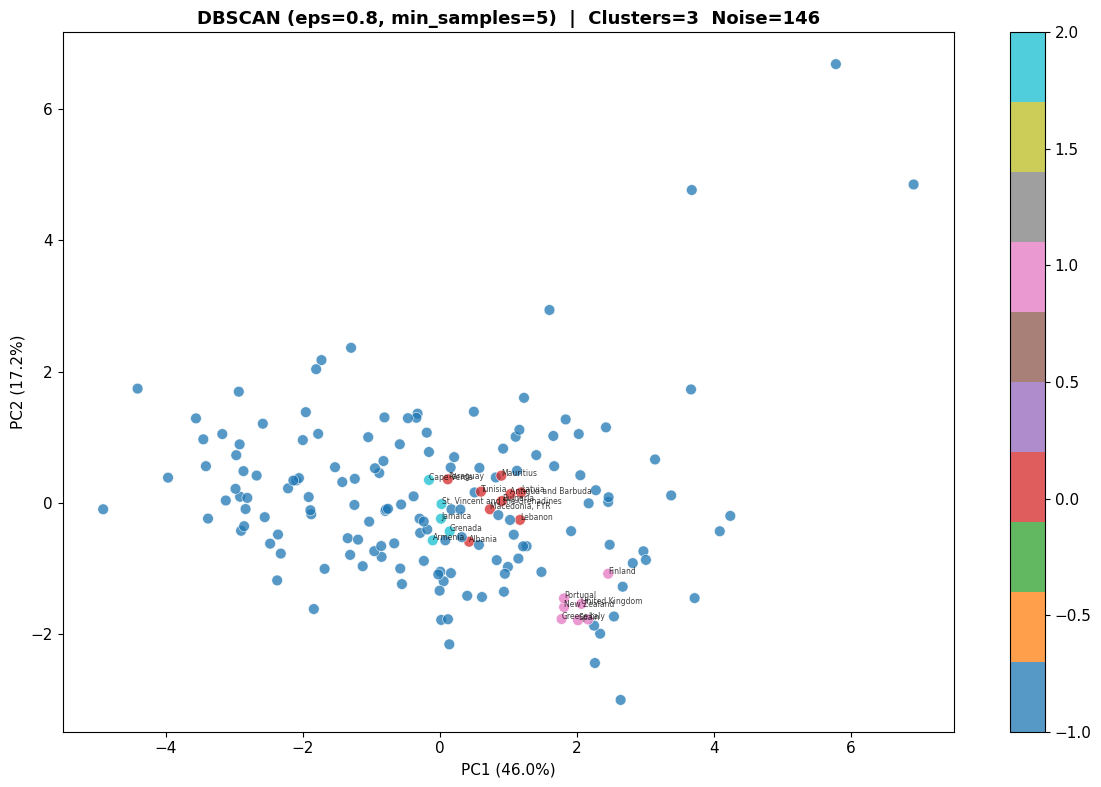

Noise / outlier countries (146): ['Afghanistan', 'Algeria', 'Angola', 'Argentina', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia', 'Fiji', 'France', 'Gabon', 'Gambia', 'Georgia', 'Germany', 'Ghana', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Haiti', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Kiribati', 'Kuwait', 'Kyrgyz Republic', 'Lao', 'Lesotho', 'Liberia', 'Libya', 'Lithuania', 'Luxembourg', '

In [34]:
# Try eps values and pick the one with best silhouette
from itertools import product

best_eps, best_ms, best_sil = 1.2, 4, -1
for eps_val, ms_val in product([0.8, 1.0, 1.2, 1.5, 1.8], [3, 4, 5]):
    labels_tmp = DBSCAN(eps=eps_val, min_samples=ms_val).fit_predict(X_clust)
    core = labels_tmp != -1
    n_c  = len(set(labels_tmp[core])) if core.sum() > 0 else 0
    if n_c >= 2:
        sil = silhouette_score(X_clust[core], labels_tmp[core])
        if sil > best_sil:
            best_sil, best_eps, best_ms = sil, eps_val, ms_val

print(f"Best DBSCAN params: eps={best_eps}, min_samples={best_ms}, silhouette={best_sil:.4f}")

dbscan    = DBSCAN(eps=best_eps, min_samples=best_ms, metric='euclidean')
db_labels = dbscan.fit_predict(X_clust)
n_db      = plot_clusters(db_labels, f'DBSCAN (eps={best_eps}, min_samples={best_ms})', annotate=True)

noise_countries = countries_all[db_labels == -1]
print(f"Noise / outlier countries ({len(noise_countries)}): {list(noise_countries)}")

core_mask = db_labels != -1
if len(set(db_labels[core_mask])) > 1:
    sil_db = silhouette_score(X_clust[core_mask], db_labels[core_mask])
    print(f"Silhouette (core points): {sil_db:.4f}")

### 8.4 Hierarchical (Agglomerative) Clustering

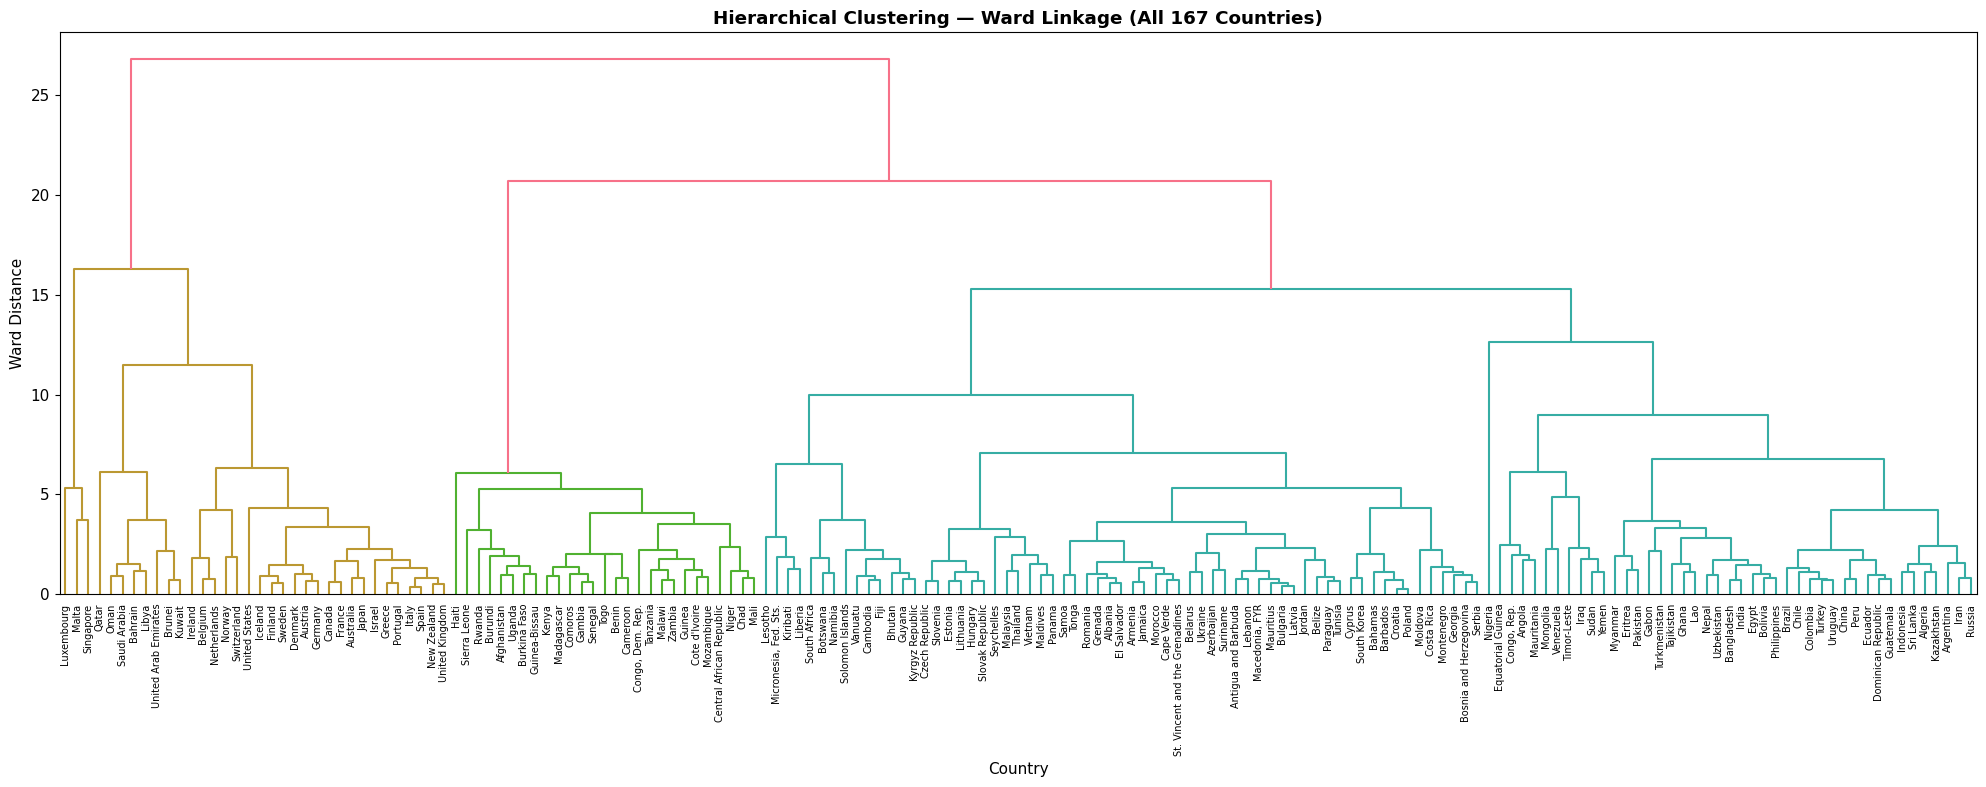

In [35]:
# Full dendrogram — 167 countries, manageable
linkage_matrix = linkage(X_clust, method='ward')

plt.figure(figsize=(20, 8))
dendrogram(linkage_matrix,
           labels=countries_all,
           leaf_rotation=90,
           leaf_font_size=7,
           color_threshold=0.7 * max(linkage_matrix[:, 2]))
plt.title('Hierarchical Clustering — Ward Linkage (All 167 Countries)', fontweight='bold')
plt.xlabel('Country'); plt.ylabel('Ward Distance')
plt.tight_layout(); plt.show()


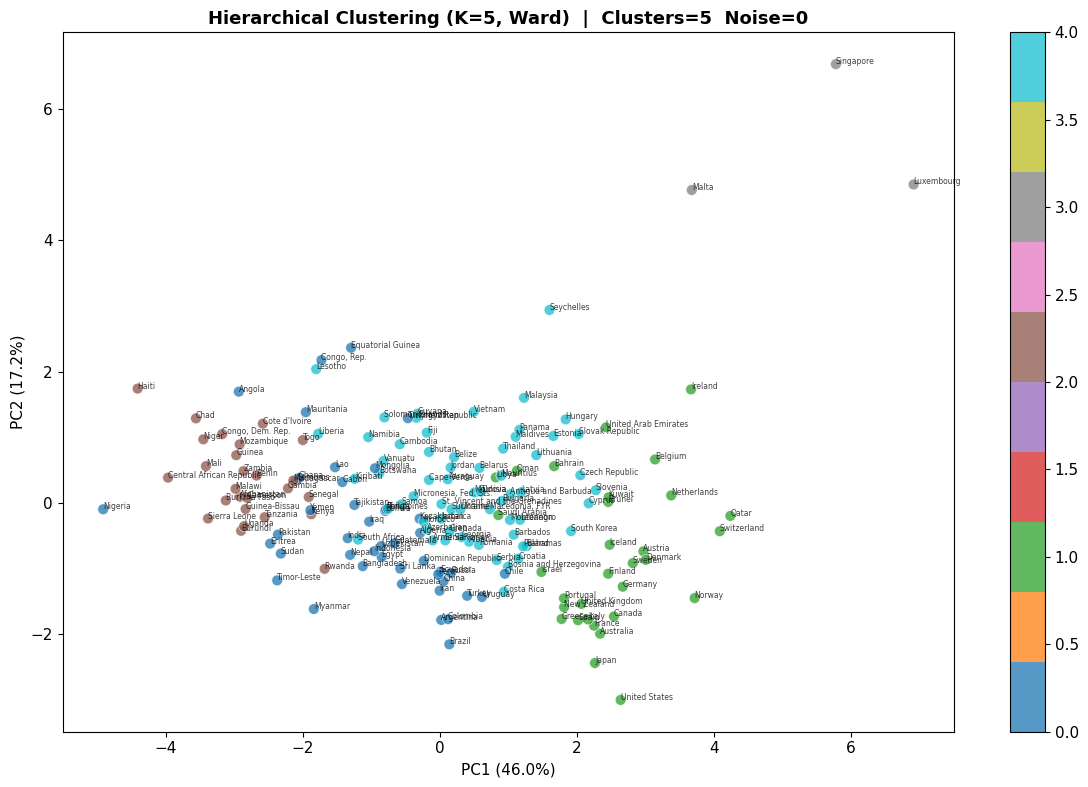

Hierarchical Silhouette: 0.2193


In [36]:
agg        = AgglomerativeClustering(n_clusters=best_k_km, linkage='ward')
agg_labels = agg.fit_predict(X_clust)
plot_clusters(agg_labels, f'Hierarchical Clustering (K={best_k_km}, Ward)', annotate=True)
print(f"Hierarchical Silhouette: {silhouette_score(X_clust, agg_labels):.4f}")


## 9. Clustering Evaluation

In [37]:
def clust_metrics(labels, X, name):
    mask = labels != -1
    Xc, lc = X[mask], labels[mask]
    n = len(set(lc))
    if n < 2:
        return dict(Algorithm=name, Clusters=n,
                    Silhouette=None, Davies_Bouldin=None, Calinski_Harabasz=None)
    return dict(Algorithm=name, Clusters=n,
                Silhouette=round(silhouette_score(Xc, lc), 4),
                Davies_Bouldin=round(davies_bouldin_score(Xc, lc), 4),
                Calinski_Harabasz=round(calinski_harabasz_score(Xc, lc), 2))

clust_eval = pd.DataFrame([
    clust_metrics(km_labels,   X_clust, 'K-Means'),
    clust_metrics(kmed_labels, X_clust, 'K-Medoids'),
    clust_metrics(db_labels,   X_clust, 'DBSCAN'),
    clust_metrics(agg_labels,  X_clust, 'Hierarchical'),
]).set_index('Algorithm')

print("=== CLUSTERING EVALUATION ===")
print(clust_eval.to_string())
print()
print("Silhouette & Calinski-Harabasz : higher is better")
print("Davies-Bouldin                 : lower is better")


=== CLUSTERING EVALUATION ===
              Clusters  Silhouette  Davies_Bouldin  Calinski_Harabasz
Algorithm                                                            
K-Means              5      0.2993          0.8718              57.65
K-Medoids            5      0.2999          0.8694              57.66
DBSCAN               3      0.4406          0.8759              42.48
Hierarchical         5      0.2193          1.3008              49.15

Silhouette & Calinski-Harabasz : higher is better
Davies-Bouldin                 : lower is better


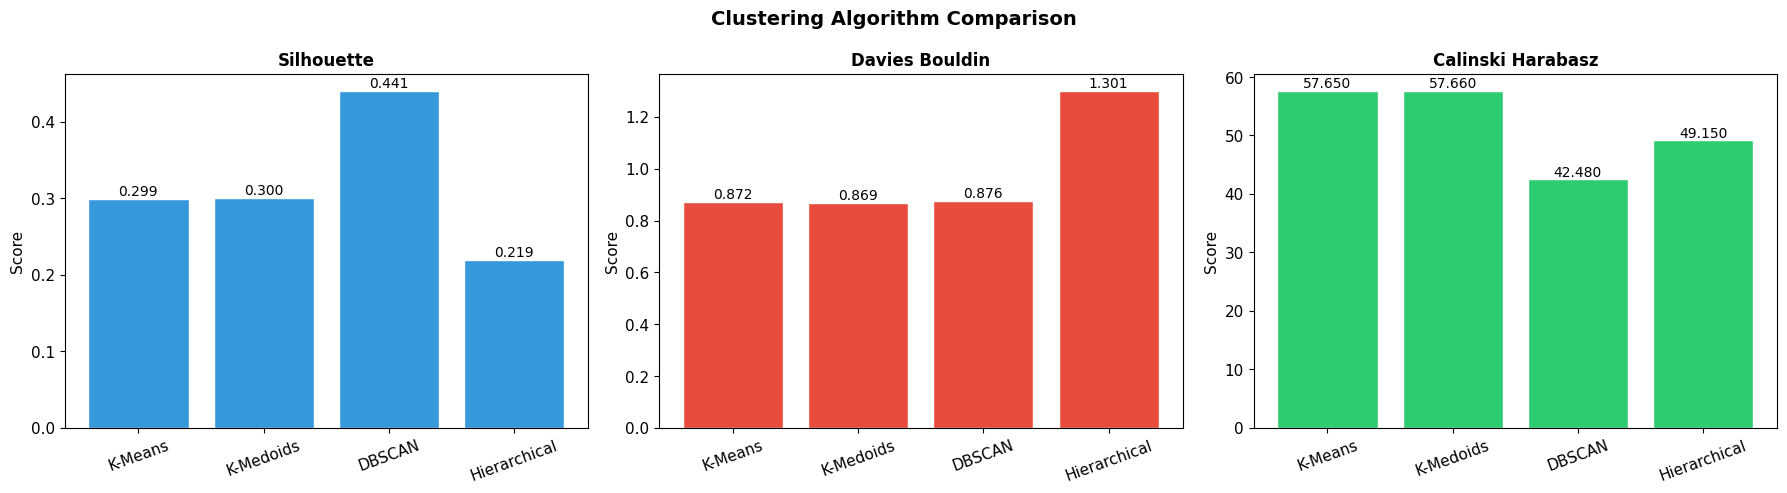

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = ['#3498db','#e74c3c','#2ecc71']

for i, (metric, color) in enumerate(
        zip(['Silhouette','Davies_Bouldin','Calinski_Harabasz'], palette)):
    data = clust_eval[metric].dropna().astype(float)
    bars = axes[i].bar(data.index, data.values, color=color, edgecolor='white')
    axes[i].set_title(metric.replace('_',' '), fontweight='bold', fontsize=12)
    axes[i].set_ylabel('Score'); axes[i].tick_params(axis='x', rotation=20)
    for bar, v in zip(bars, data.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     v + max(data.values)*0.01, f'{v:.3f}', ha='center', fontsize=10)

plt.suptitle('Clustering Algorithm Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


## 10. Country Segment Insights

In [39]:
df['Cluster'] = km_labels
seg = df.groupby('Cluster').agg(
    Count      =('country','count'),
    Dev_Rate   =('is_developed','mean'),
    Avg_GDPP   =('gdpp','mean'),
    Avg_Income =('income','mean'),
    Life_Expec =('life_expec','mean'),
    Child_Mort =('child_mort','mean'),
    Inflation  =('inflation','mean'),
).round(2)
print("=== CLUSTER PROFILES ===")
print(seg.to_string())


=== CLUSTER PROFILES ===
         Count  Dev_Rate  Avg_GDPP  Avg_Income  Life_Expec  Child_Mort  Inflation
Cluster                                                                          
0           84      0.58   6581.81    12801.07       73.00       21.61       7.62
1           47      0.00   1900.26     3870.70       59.21       90.79       9.95
2            3      1.00  57566.67    64033.33       81.43        4.13       2.47
3           32      1.00  42118.75    44021.88       80.08        5.18       2.51
4            1      0.00   2330.00     5150.00       60.50      130.00     104.00


In [40]:
# Countries per cluster
print("=== COUNTRIES BY CLUSTER ===\n")
for cid in sorted(df['Cluster'].unique()):
    cluster_countries = df[df['Cluster'] == cid]['country'].tolist()
    print(f"Cluster {cid} ({len(cluster_countries)} countries):")
    print("  " + ", ".join(cluster_countries))
    print()


=== COUNTRIES BY CLUSTER ===

Cluster 0 (84 countries):
  Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Azerbaijan, Bahrain, Bangladesh, Barbados, Belarus, Belize, Bhutan, Bolivia, Bosnia and Herzegovina, Brazil, Bulgaria, Cambodia, Cape Verde, Chile, China, Colombia, Costa Rica, Croatia, Dominican Republic, Ecuador, Egypt, El Salvador, Estonia, Fiji, Georgia, Grenada, Guatemala, Guyana, Hungary, India, Indonesia, Iran, Jamaica, Jordan, Kazakhstan, Kyrgyz Republic, Latvia, Lebanon, Libya, Lithuania, Macedonia, FYR, Malaysia, Maldives, Mauritius, Micronesia, Fed. Sts., Moldova, Mongolia, Montenegro, Morocco, Myanmar, Nepal, Oman, Panama, Paraguay, Peru, Philippines, Poland, Romania, Russia, Samoa, Saudi Arabia, Serbia, Seychelles, Slovak Republic, Sri Lanka, St. Vincent and the Grenadines, Suriname, Tajikistan, Thailand, Tonga, Tunisia, Turkey, Turkmenistan, Ukraine, Uruguay, Uzbekistan, Vanuatu, Venezuela, Vietnam

Cluster 1 (47 countries):
  Afghanistan, Angola, Benin, Bo

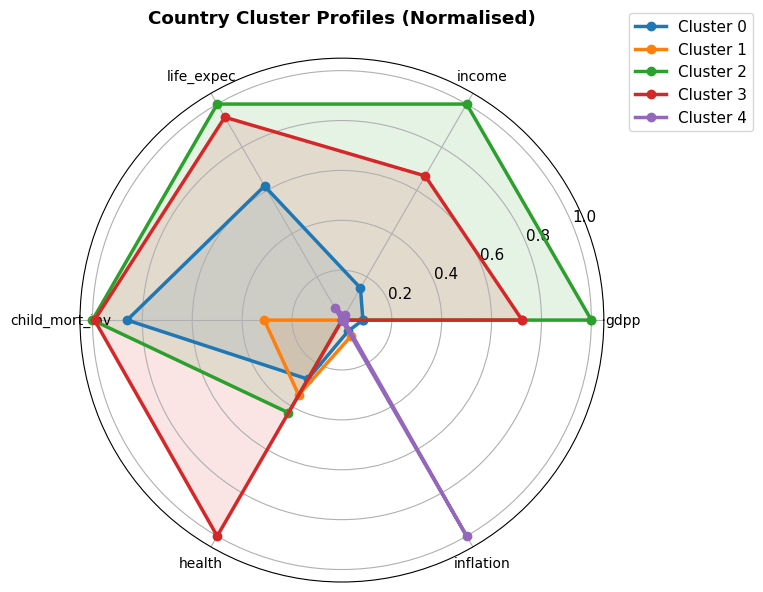

In [41]:
# Radar chart — normalised cluster profiles
radar_cols = ['gdpp','income','life_expec','child_mort','health','inflation']
seg_raw    = df.groupby('Cluster')[radar_cols].mean()
# invert child_mort for radar (lower = better → higher on chart)
seg_raw_radar = seg_raw.copy()
seg_raw_radar['child_mort'] = seg_raw_radar['child_mort'].max() - seg_raw_radar['child_mort']
seg_norm = (seg_raw_radar - seg_raw_radar.min()) / (seg_raw_radar.max() - seg_raw_radar.min() + 1e-9)

N_feat  = len(radar_cols)
angles  = np.linspace(0, 2*np.pi, N_feat, endpoint=False).tolist() + [0]
palette = plt.cm.tab10.colors
labels_r = [c.replace('child_mort','child_mort_inv') for c in radar_cols]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for cid in seg_norm.index:
    vals = seg_norm.loc[cid].tolist() + [seg_norm.loc[cid].iloc[0]]
    ax.plot(angles, vals, 'o-', linewidth=2.5, color=palette[cid],
            label=f'Cluster {cid}')
    ax.fill(angles, vals, alpha=0.12, color=palette[cid])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_r, fontsize=10)
ax.set_title('Country Cluster Profiles (Normalised)', fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout(); plt.show()


## 11. Final Summary

In [42]:
print("=" * 65)
print("    CUSTOMER INTELLIGENCE SYSTEM — FINAL RESULTS SUMMARY")
print("=" * 65)
print(f"  Dataset     : Country Data (Kaggle — rohan0301)")
print(f"  Samples     : {len(df)}  |  Features: {len(FEATURES)}")
print(f"  Target      : is_developed (median dev-score split)")
print()

print("--- CLASSIFICATION LEADERBOARD (sorted by ROC-AUC) ---")
top = comp_df.sort_values('ROC_AUC', ascending=False)
for rank, (name, row) in enumerate(top.iterrows(), 1):
    print(f"  {rank:2d}. {name:26s}  AUC={row['ROC_AUC']:.4f}  "
          f"F1={row['F1']:.4f}  Acc={row['Accuracy']:.4f}")

print()
print("--- CLUSTERING RESULTS ---")
for alg, row in clust_eval.iterrows():
    if row['Silhouette'] is not None:
        print(f"  {alg:18s}  K={int(row['Clusters'])}  "
              f"Silhouette={row['Silhouette']:.4f}  "
              f"DB={row['Davies_Bouldin']:.4f}")

print()
print("--- CLUSTER LABELS ---")
for cid, row in seg.iterrows():
    tag = 'HIGH DEVELOPMENT' if row['Dev_Rate'] > 0.7 else (
          'MID DEVELOPMENT'  if row['Dev_Rate'] > 0.3 else
          'LOW DEVELOPMENT')
    print(f"  Cluster {cid}: {int(row['Count'])} countries | "
          f"Avg GDPP=${row['Avg_GDPP']:,.0f} | "
          f"Life Exp={row['Life_Expec']:.1f} | {tag}")

print()
best_m  = comp_df['ROC_AUC'].idxmax()
best_cl = clust_eval['Silhouette'].dropna().idxmax()
print(f"  Best classifier : {best_m} (AUC={comp_df.loc[best_m,'ROC_AUC']:.4f})")
print(f"  Best clustering : {best_cl} (Silhouette={clust_eval.loc[best_cl,'Silhouette']:.4f})")
print("=" * 65)


    CUSTOMER INTELLIGENCE SYSTEM — FINAL RESULTS SUMMARY
  Dataset     : Country Data (Kaggle — rohan0301)
  Samples     : 167  |  Features: 9
  Target      : is_developed (median dev-score split)

--- CLASSIFICATION LEADERBOARD (sorted by ROC-AUC) ---
   1. Gradient Boosting           AUC=0.9965  F1=0.8718  Acc=0.8529
   2. Naive Bayes                 AUC=0.9931  F1=0.8718  Acc=0.8529
   3. Random Forest               AUC=0.9896  F1=0.8947  Acc=0.8824
   4. Logistic Regression         AUC=0.9896  F1=0.8500  Acc=0.8235
   5. XGBoost                     AUC=0.9862  F1=0.8718  Acc=0.8529
   6. SVM                         AUC=0.9827  F1=0.8293  Acc=0.7941
   7. AdaBoost                    AUC=0.9792  F1=0.8205  Acc=0.7941
   8. Stacking                    AUC=0.9758  F1=0.8095  Acc=0.7647
   9. LightGBM                    AUC=0.9723  F1=0.8095  Acc=0.7647
  10. KNN                         AUC=0.9619  F1=0.8293  Acc=0.7941
  11. Decision Tree               AUC=0.7353  F1=0.7805  Acc=0.7353